<a href="https://colab.research.google.com/github/DulSamindika/XAI-for-Risk-Management/blob/main/research_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!apt-get install -y mysql-server > /dev/null 2>&1
!service mysql start
print('MySQL server started successfully.')

# Install Python MySQL connector
!pip install mysql-connector-python -q
print('mysql-connector-python installed.')

# Install imbalanced-learn for SMOTE later
!pip install imbalanced-learn -q
print('imbalanced-learn installed.')

 * Starting MySQL database server mysqld
su: warning: cannot change directory to /nonexistent: No such file or directory
   ...done.
MySQL server started successfully.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 35.9 MB/s eta 0:00:00
mysql-connector-python installed.
imbalanced-learn installed.


In [ ]:
!mysql -e "ALTER USER 'root'@'localhost' IDENTIFIED WITH mysql_native_password BY 'tawos_root_2024'; FLUSH PRIVILEGES;"
print('Root password set: tawos_root_2024')

Root password set: tawos_root_2024


In [ ]:
from google.colab import files
import os

# OPTION B: Mount Google Drive (recommended for large files)
from google.colab import drive
drive.mount('/content/drive')

# Set your path here — change folder name if different
SQL_FILE = '/content/drive/MyDrive/TAWOS/TAWOS.sql'

# Verify the file exists
if os.path.exists(SQL_FILE):
    size_mb = os.path.getsize(SQL_FILE) / (1024*1024)
    print(f'File found: {SQL_FILE}')
    print(f'File size:  {size_mb:.1f} MB')
else:
    print('FILE NOT FOUND — check your path')
    print('Expected path:', SQL_FILE)

Mounted at /content/drive
File found: /content/drive/MyDrive/TAWOS/TAWOS.sql
File size:  4114.0 MB


In [ ]:
import subprocess

# Create the database first
!mysql -u root -ptawos_root_2024 -e "CREATE DATABASE IF NOT EXISTS TAWOS;"
print('Database TAWOS created.')

# Import the SQL dump — this is the main loading step
print('Loading SQL file into MySQL... (this may take 5-15 minutes)')
result = subprocess.run(
    f'mysql -u root -ptawos_root_2024 TAWOS < "{SQL_FILE}"',
    shell=True, capture_output=True, text=True
)

if result.returncode == 0:
    print('SQL file loaded successfully!')
else:
    print('Error loading SQL file:')
    print(result.stderr)

# Verify tables loaded
!mysql -u root -ptawos_root_2024 -e "USE TAWOS; SHOW TABLES;"

mysql: [Warning] Using a password on the command line interface can be insecure.
Database TAWOS created.
Loading SQL file into MySQL... (this may take 5-15 minutes)
SQL file loaded successfully!
mysql: [Warning] Using a password on the command line interface can be insecure.
+------------------+
| Tables_in_TAWOS  |
+------------------+
| Affected_Version |
| Change_Log       |
| Comment          |
| Component        |
| Fix_Version      |
| Issue            |
| Issue_Component  |
| Issue_Link       |
| Project          |
| Repository       |
| Sprint           |
| User             |
| Version          |
+------------------+


In [ ]:
import mysql.connector
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Connect to MySQL
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='tawos_root_2024',
    database='TAWOS'
)
print('Connected to MySQL TAWOS database.')

def run_query(sql, conn=conn):
    """Helper: run a SQL query and return a DataFrame."""
    return pd.read_sql(sql, conn)

# Show all tables
tables = run_query('SHOW TABLES;')
print('\nTables in TAWOS database:')
print(tables.to_string(index=False))

Connected to MySQL TAWOS database.

Tables in TAWOS database:
 Tables_in_TAWOS
Affected_Version
      Change_Log
         Comment
       Component
     Fix_Version
           Issue
 Issue_Component
      Issue_Link
         Project
      Repository
          Sprint
            User
         Version


In [ ]:
# Get row counts for all tables
table_names = [
    'Repository', 'Project', 'User', 'Issue',
    'Sprint',
    'Comment', 'Change_Log',
    'Issue_Link', 'Component', 'Version'
]

print(f'{'Table':<25} {'Rows':>12}')
print('-' * 40)
for t in table_names:
    try:
        count = run_query(f'SELECT COUNT(*) as cnt FROM `{t}`;')['cnt'][0]
        print(f'{t:<25} {count:>12,}')
    except Exception as e:
        print(f'{t:<25} ERROR: {e}')

print('\n--- Issue table columns ---')
cols = run_query('DESCRIBE Issue;')
print(cols[['Field','Type']].to_string(index=False))

Table                             Rows
----------------------------------------
Repository                          12
Project                             39
User                           206,162
Issue                          458,232
Sprint                           4,594
Comment                      1,518,327
Change_Log                   9,253,419
Issue_Link                     246,587
Component                        2,001
Version                          6,911

--- Issue table columns ---
                               Field         Type
                                  ID          int
                             Jira_ID          int
                           Issue_Key varchar(512)
                                 URL varchar(512)
                               Title varchar(512)
                         Description   mediumtext
                    Description_Text   mediumtext
                    Description_Code   mediumtext
                                Type varchar(128)
 

In [ ]:
print('Extracting Issue table (technical features)...')

issues = run_query("""
    SELECT
        i.ID                                    AS issue_id,
        i.Project_ID                            AS project_id,
        i.Creator_ID                            AS creator_id,
        i.Issue_Key                             AS issue_key,
        i.Type                                  AS issue_type,
        i.Priority                              AS priority,
        i.Status                                AS status,
        i.Resolution                            AS resolution,
        i.Story_Point                           AS story_point,
        i.Timespent                             AS timespent,
        i.In_Progress_Minutes                   AS in_progress_minutes,
        i.Total_Effort_Minutes                  AS total_effort_minutes,
        i.Resolution_Time_Minutes                AS resolution_time_minutes,
        i.Creation_Date                         AS creation_date,
        i.Resolution_Date                       AS resolution_date,
        i.Story_Point_Changed_After_Estimation  AS sp_changed_after_est,
        i.Title_Changed_After_Estimation        AS title_changed_after_est,
        i.Description_Changed_After_Estimation  AS desc_changed_after_est,
        i.Sprint_ID                             AS sprint_id
    FROM Issue i
    WHERE i.Story_Point IS NOT NULL
      AND i.Story_Point > 0
""")

print(f'Issues loaded: {len(issues):,} rows')
print(f'Projects covered: {issues["project_id"].nunique()}')
print('\nSample:')
issues.head(3)

Extracting Issue table (technical features)...
Issues loaded: 63,011 rows
Projects covered: 39

Sample:


,issue_id,project_id,creator_id,issue_key,issue_type,priority,status,resolution,story_point,timespent,in_progress_minutes,total_effort_minutes,resolution_time_minutes,creation_date,resolution_date,sp_changed_after_est,title_changed_after_est,desc_changed_after_est,sprint_id
0,65,1,68.0,XD-3768,Bug,Major,To Do,None,1.0,NaN,0.0,0.0,0.0,2017-07-10 13:41:25,NaT,0,0,0,NaN
1,66,1,69.0,XD-3767,Bug,Trivial,To Do,None,1.0,NaN,0.0,0.0,0.0,2017-06-26 16:26:27,NaT,0,0,0,NaN
2,67,1,70.0,XD-3766,Bug,Major,To Do,None,10.0,NaN,0.0,0.0,0.0,2017-05-19 22:28:43,NaT,0,0,0,NaN


In [ ]:
print('Extracting Sprint table...')

sprints = run_query("""
    SELECT
        s.ID          AS sprint_id,
        s.Project_ID  AS project_id,
        s.Name        AS sprint_name,
        s.State       AS sprint_state,
        s.Start_Date  AS sprint_start,
        s.End_Date    AS sprint_end,
        s.Complete_Date AS sprint_completed
    FROM Sprint s
    WHERE s.State = 'closed'
""")

print(f'Closed sprints loaded: {len(sprints):,}')

Extracting Sprint table...
Closed sprints loaded: 4,507


In [ ]:
print('Joining Issues and Sprints...')

issues_with_sprint = pd.merge(
    issues,
    sprints[['sprint_id', 'sprint_name', 'sprint_start', 'sprint_end', 'sprint_completed']],
    on='sprint_id',
    how='left'
)

print(f'Issues with sprint info loaded: {len(issues_with_sprint):,} rows')
print('\nSample:')
issues_with_sprint.head(3)

Joining Issues and Sprints...
Issues with sprint info loaded: 63,011 rows

Sample:


,issue_id,project_id,creator_id,issue_key,issue_type,priority,status,resolution,story_point,timespent,...,creation_date,resolution_date,sp_changed_after_est,title_changed_after_est,desc_changed_after_est,sprint_id,sprint_name,sprint_start,sprint_end,sprint_completed
0,65,1,68.0,XD-3768,Bug,Major,To Do,None,1.0,NaN,...,2017-07-10 13:41:25,NaT,0,0,0,NaN,NaN,NaN,NaN,NaT
1,66,1,69.0,XD-3767,Bug,Trivial,To Do,None,1.0,NaN,...,2017-06-26 16:26:27,NaT,0,0,0,NaN,NaN,NaN,NaN,NaT
2,67,1,70.0,XD-3766,Bug,Major,To Do,None,10.0,NaN,...,2017-05-19 22:28:43,NaT,0,0,0,NaN,NaN,NaN,NaN,NaT


In [ ]:
print('Extracting Change_Log table (human + process factors)...')
print('NOTE: This table is large — may take 1-2 minutes...')

changelogs = run_query("""
    SELECT
        cl.Issue_ID     AS issue_id,
        cl.Change_Type  AS change_type,
        cl.Creation_Date AS change_date
    FROM Change_Log cl
    WHERE cl.Change_Type IN ('PEOPLE', 'STATUS', 'STORY_POINT', 'DESCRIPTION')
""")

print(f'Change logs loaded: {len(changelogs):,}')
print('\nBreakdown by change type:')
print(changelogs['change_type'].value_counts().to_string())

Extracting Change_Log table (human + process factors)...
NOTE: This table is large — may take 1-2 minutes...
Change logs loaded: 2,526,526

Breakdown by change type:
change_type
STATUS         1779677
PEOPLE          349551
DESCRIPTION     348103
STORY_POINT      49195


In [ ]:
print('Extracting Issue_Link table (process dependency factor)...')

issue_links = run_query("""
    SELECT Issue_ID AS issue_id
    FROM Issue_Link
""")

print(f'Issue links loaded: {len(issue_links):,}')

Extracting Issue_Link table (process dependency factor)...
Issue links loaded: 246,587


In [ ]:
# ─── TECHNICAL FEATURES (already in issues table) ────
tech_cols = [
    'issue_id', 'project_id', 'creator_id',
    'issue_type', 'priority', 'status', 'resolution',
    'story_point', 'timespent', 'in_progress_minutes',
    'total_effort_minutes', 'resolution_time_minutes',
    'sp_changed_after_est', 'title_changed_after_est', 'desc_changed_after_est'
]
tech_df = issues[tech_cols].copy()

# Convert booleans stored as 0/1 or True/False
bool_cols = ['sp_changed_after_est', 'title_changed_after_est', 'desc_changed_after_est']
for col in bool_cols:
    tech_df[col] = pd.to_numeric(tech_df[col], errors='coerce').fillna(0).astype(int)

# Binary: is this issue a bug?
tech_df['is_bug'] = (tech_df['issue_type'].str.lower() == 'bug').astype(int)

# Binary: is this issue high priority?
tech_df['is_high_priority'] = (
    tech_df['priority'].str.lower().isin(['highest', 'critical', 'blocker'])
).astype(int)

# Effort overrun: actual effort minus estimated (story_point * 60 mins)
tech_df['effort_overrun'] = (
    tech_df['total_effort_minutes'].fillna(0) -
    (tech_df['story_point'].fillna(0) * 60)
).clip(lower=0)

print('Technical features prepared.')
print(f'Shape: {tech_df.shape}')
print(tech_df[['issue_id','story_point','is_bug','effort_overrun']].head(3))

Technical features prepared.
Shape: (63011, 18)
   issue_id  story_point  is_bug  effort_overrun
0        65          1.0       1             0.0
1        66          1.0       1             0.0
2        67         10.0       1             0.0


In [ ]:
print('Extracting Comment table...')
comments = run_query("""
    SELECT
        c.Issue_ID AS issue_id,
        c.Author_ID AS Author_ID,
        c.Creation_Date AS comment_date
    FROM Comment c
""")

print(f'Comments loaded: {len(comments):,} rows')
print('\nSample:')
comments.head(3)

print('\nDescribing the Comment table to find correct column names:')
comment_schema = run_query('DESCRIBE Comment;')
print(comment_schema[['Field', 'Type']].to_string(index=False))

Extracting Comment table...
Comments loaded: 1,518,327 rows

Sample:

Describing the Comment table to find correct column names:
        Field       Type
           ID        int
      Comment mediumtext
 Comment_Text mediumtext
 Comment_Code mediumtext
Creation_Date   datetime
    Author_ID        int
     Issue_ID        int


In [ ]:
print('Run the cell oKPd5TZqNwNR again.')
# ─── HUMAN FEATURES (from Change_Log + Comment) ───────

# Reassignments per issue (PEOPLE changes = team instability)
people_chg = changelogs[changelogs['change_type'] == 'PEOPLE']
reassignments = people_chg.groupby('issue_id').size().reset_index(name='reassignment_count')

# Status transitions per issue (workflow churn = process instability — also human indicator)
status_chg = changelogs[changelogs['change_type'] == 'STATUS']
status_churn = status_chg.groupby('issue_id').size().reset_index(name='status_change_count')

# Comment volume per issue (communication intensity)
comment_vol = comments.groupby('issue_id').size().reset_index(name='comment_count')

# Unique commenters per issue (collaboration breadth)
unique_commenters = comments.groupby('issue_id')['Author_ID'].nunique().reset_index(
    name='unique_commenters')

# Merge all human signals onto issues
human_df = tech_df[['issue_id']].copy()
human_df = human_df.merge(reassignments,     on='issue_id', how='left')
human_df = human_df.merge(status_churn,      on='issue_id', how='left')
human_df = human_df.merge(comment_vol,       on='issue_id', how='left')
human_df = human_df.merge(unique_commenters, on='issue_id', how='left')
human_df = human_df.fillna(0)

print('Human features prepared.')
print(f'Shape: {human_df.shape}')
print(human_df.describe().round(2))

Run the cell oKPd5TZqNwNR again.
Human features prepared.
Shape: (63011, 5)
        issue_id  reassignment_count  status_change_count  comment_count  \
count   63011.00            63011.00             63011.00       63011.00   
mean   231486.67                1.08                 4.63           3.14   
std    137440.19                1.88                 3.27           5.74   
min        65.00                0.00                 0.00           0.00   
25%    176537.50                0.00                 3.00           1.00   
50%    237300.00                1.00                 4.00           2.00   
75%    345858.50                1.00                 5.00           4.00   
max    505453.00               41.00                65.00         186.00   

       unique_commenters  
count           63011.00  
mean                1.71  
std                 2.25  
min                 0.00  
25%                 1.00  
50%                 1.00  
75%                 2.00  
max               118.0

In [ ]:
# ─── PROCESS FEATURES (from Change_Log + Issue_Link) ─────────────────────────

# Story point changes (scope volatility)
sp_chg = changelogs[changelogs['change_type'] == 'STORY_POINT']
sp_volatility = sp_chg.groupby('issue_id').size().reset_index(name='sp_change_count')

# Description/title changes (requirement volatility)
desc_chg = changelogs[changelogs['change_type'] == 'DESCRIPTION']
req_volatility = desc_chg.groupby('issue_id').size().reset_index(name='req_change_count')

# Dependency count (process complexity)
dependency_count = issue_links.groupby('issue_id').size().reset_index(name='dependency_count')

# Merge all process signals
process_df = tech_df[['issue_id',
                       'sp_changed_after_est',
                       'desc_changed_after_est']].copy()
process_df = process_df.merge(sp_volatility,    on='issue_id', how='left')
process_df = process_df.merge(req_volatility,   on='issue_id', how='left')
process_df = process_df.merge(dependency_count, on='issue_id', how='left')
process_df = process_df.fillna(0)

print('Process features prepared.')
print(f'Shape: {process_df.shape}')
print(process_df.describe().round(2))

Process features prepared.
Shape: (63011, 6)
        issue_id  sp_changed_after_est  desc_changed_after_est  \
count   63011.00              63011.00                 63011.0   
mean   231486.67                  0.12                     0.0   
std    137440.19                  0.33                     0.0   
min        65.00                  0.00                     0.0   
25%    176537.50                  0.00                     0.0   
50%    237300.00                  0.00                     0.0   
75%    345858.50                  0.00                     0.0   
max    505453.00                  1.00                     0.0   

       sp_change_count  req_change_count  dependency_count  
count         63011.00          63011.00          63011.00  
mean              0.71              0.79              0.64  
std               0.76              1.70              1.34  
min               0.00              0.00              0.00  
25%               0.00              0.00              0

In [ ]:
# Combine all per-issue features into one dataframe
all_issue_features = tech_df.merge(human_df,   on='issue_id', how='left') \
                             .merge(process_df, on='issue_id', how='left')

# Join to sprint membership
sprint_issues = issues_with_sprint.merge(all_issue_features, on='issue_id', how='inner')

# Only keep issues in closed sprints
closed_sprint_ids = set(sprints['sprint_id'])
sprint_issues = sprint_issues[sprint_issues['sprint_id'].isin(closed_sprint_ids)]

print(f'Sprint-issue joined rows: {len(sprint_issues):,}')
print(f'Unique closed sprints:    {sprint_issues["sprint_id"].nunique():,}')
print(f'Unique projects:          {sprint_issues["project_id_x"].nunique()}')

Sprint-issue joined rows: 28,914
Unique closed sprints:    2,804
Unique projects:          36


In [ ]:
# ─── AGGREGATE TO SPRINT LEVEL ───────────────────────────────────────────────
sprint_df = sprint_issues.groupby('sprint_id').agg(

    # ── TECHNICAL FEATURES ──────────────────────────────────────────────────
    total_issues            = ('issue_id',               'count'),
    story_pts_planned       = ('story_point_x',            'sum'),
    bug_count               = ('is_bug',                 'sum'),
    high_priority_count     = ('is_high_priority',       'sum'),
    avg_resolution_mins     = ('resolution_time_minutes_x','mean'),
    avg_effort_mins         = ('total_effort_minutes_x',   'mean'),
    total_effort_overrun    = ('effort_overrun',         'sum'),
    scope_changed_count     = ('sp_changed_after_est_x',   'sum'),
    title_changed_count     = ('title_changed_after_est_x','sum'),

    # ── HUMAN FEATURES ──────────────────────────────────────────────────────
    unique_contributors     = ('creator_id_x',             'nunique'),
    total_reassignments     = ('reassignment_count',     'sum'),
    total_status_churn      = ('status_change_count',    'sum'),
    total_comments          = ('comment_count',          'sum'),
    avg_unique_commenters   = ('unique_commenters',      'mean'),

    # ── PROCESS FEATURES ────────────────────────────────────────────────────
    req_change_count        = ('req_change_count',       'sum'),
    sp_change_count         = ('sp_change_count',        'sum'),
    desc_changed_count      = ('desc_changed_after_est_x', 'sum'),
    total_dependencies      = ('dependency_count',       'sum'),

).reset_index()

# Derived ratios
sprint_df['bug_ratio']          = sprint_df['bug_count'] / sprint_df['total_issues'].replace(0,1)
sprint_df['high_priority_ratio']= sprint_df['high_priority_count'] / sprint_df['total_issues'].replace(0,1)
sprint_df['avg_story_pts']      = sprint_df['story_pts_planned'] / sprint_df['total_issues'].replace(0,1)
sprint_df['scope_change_ratio'] = sprint_df['scope_changed_count'] / sprint_df['total_issues'].replace(0,1)
sprint_df['reassignment_ratio'] = sprint_df['total_reassignments'] / sprint_df['total_issues'].replace(0,1)

print(f'Sprint-level matrix shape: {sprint_df.shape}')
print(sprint_df.head(3))

Sprint-level matrix shape: (2804, 24)
   sprint_id  total_issues  story_pts_planned  bug_count  high_priority_count  \
0        1.0             7               10.0          3                    0   
1        2.0             9               16.0          5                    0   
2        3.0             1                1.0          1                    1   

   avg_resolution_mins  avg_effort_mins  total_effort_overrun  \
0         75347.714286      3542.285714               24315.0   
1         46683.888889     16209.777778              145048.0   
2         10444.000000     10425.000000               10365.0   

   scope_changed_count  title_changed_count  ...  avg_unique_commenters  \
0                    0                    2  ...               0.428571   
1                    0                    1  ...               0.555556   
2                    0                    0  ...               0.000000   

   req_change_count  sp_change_count  desc_changed_count  total_dependencie

In [ ]:
# Story points actually completed (Status = 'Done' or Resolution is not null)
done_mask = (
    (sprint_issues['status_x'].str.lower() == 'done') |
    (sprint_issues['resolution_x'].notna() & (sprint_issues['resolution_x'].str.lower() != 'unresolved'))
)

done_pts = sprint_issues[done_mask].groupby('sprint_id')['story_point_x'].sum().reset_index()
done_pts.columns = ['sprint_id', 'story_pts_done']

sprint_df = sprint_df.merge(done_pts, on='sprint_id', how='left')
sprint_df['story_pts_done'] = sprint_df['story_pts_done'].fillna(0)

# Completion rate: 1.0 = 100% complete, 0.0 = nothing done
sprint_df['completion_rate'] = (
    sprint_df['story_pts_done'] /
    sprint_df['story_pts_planned'].replace(0, np.nan)
).fillna(0).clip(0, 1)

print('Completion rate stats:')
print(sprint_df['completion_rate'].describe().round(3))

Completion rate stats:
count    2804.000
mean        0.969
std         0.124
min         0.000
25%         1.000
50%         1.000
75%         1.000
max         1.000
Name: completion_rate, dtype: float64


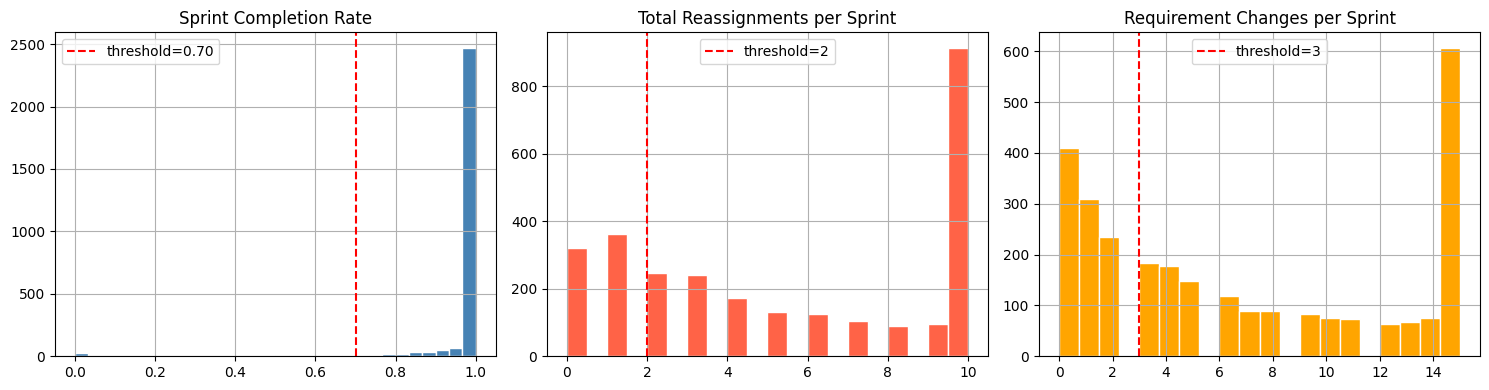

Chart saved to Google Drive.


In [ ]:
import matplotlib.pyplot as plt

# ── Check distributions BEFORE deciding thresholds ────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sprint_df['completion_rate'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(0.70, color='red', linestyle='--', label='threshold=0.70')
axes[0].set_title('Sprint Completion Rate')
axes[0].legend()

sprint_df['total_reassignments'].clip(0,10).hist(bins=20, ax=axes[1], color='tomato', edgecolor='white')
axes[1].axvline(2, color='red', linestyle='--', label='threshold=2')
axes[1].set_title('Total Reassignments per Sprint')
axes[1].legend()

sprint_df['req_change_count'].clip(0,15).hist(bins=20, ax=axes[2], color='orange', edgecolor='white')
axes[2].axvline(3, color='red', linestyle='--', label='threshold=3')
axes[2].set_title('Requirement Changes per Sprint')
axes[2].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TAWOS/threshold_distributions.png', dpi=150)
plt.show()
print('Chart saved to Google Drive.')

In [ ]:
# Step 1: print percentiles to see your actual data distribution
print("=== Completion Rate Percentiles ===")
print(sprint_df['completion_rate'].quantile([.25,.50,.75,.90]).round(3))

print("\n=== Reassignment Percentiles ===")
print(sprint_df['total_reassignments'].quantile([.25,.50,.75,.90]).round(1))

print("\n=== Req Change Percentiles ===")
print(sprint_df['req_change_count'].quantile([.25,.50,.75,.90]).round(1))

# Step 2: set thresholds for low, medium, and high risk
# Use fixed thresholds for completion rate due to its distribution
COMPLETION_HIGH_RISK_THRESHOLD = 0.75 # e.g., below 75% is high risk

# For reassignments and req changes, use percentiles
P75_REASSIGN    = sprint_df['total_reassignments'].quantile(0.75)
P50_REASSIGN    = sprint_df['total_reassignments'].quantile(0.50)
P75_REQ_CHANGES = sprint_df['req_change_count'].quantile(0.75)
P50_REQ_CHANGES = sprint_df['req_change_count'].quantile(0.50)

print(f"\nDerived thresholds:")
print(f"  High Risk Completion rate below : {COMPLETION_HIGH_RISK_THRESHOLD:.2f}")
print(f"  Medium Risk Completion rate     : >= {COMPLETION_HIGH_RISK_THRESHOLD:.2f} (for medium check)")
print(f"  High Risk Reassignments above   : {P75_REASSIGN:.0f}")
print(f"  Medium Risk Reassignments       : > {P50_REASSIGN:.0f} and <= {P75_REASSIGN:.0f}")
print(f"  High Risk Req changes above     : {P75_REQ_CHANGES:.0f}")
print(f"  Medium Risk Req changes         : > {P50_REQ_CHANGES:.0f} and <= {P75_REQ_CHANGES:.0f}")

# Step 3: apply a 3-level risk label (0=Low, 1=Medium, 2=High)
sprint_df['risk_level'] = 0 # Default to Low Risk

# High Risk conditions (if ANY of these are met)
high_risk_mask = (
    (sprint_df['completion_rate']     < COMPLETION_HIGH_RISK_THRESHOLD)   |
    (sprint_df['total_reassignments'] > P75_REASSIGN)     |
    (sprint_df['req_change_count']    > P75_REQ_CHANGES)
)
sprint_df.loc[high_risk_mask, 'risk_level'] = 2

# Medium Risk conditions (if NOT High Risk AND ALL these are met for 'medium')
# For completion rate, "medium" simply means it's not in the high-risk zone
medium_comp_mask     = (sprint_df['completion_rate'] >= COMPLETION_HIGH_RISK_THRESHOLD)
medium_reassign_mask = (sprint_df['total_reassignments'] >  P50_REASSIGN)   & (sprint_df['total_reassignments'] <= P75_REASSIGN)
medium_req_chg_mask  = (sprint_df['req_change_count']    >  P50_REQ_CHANGES) & (sprint_df['req_change_count']    <= P75_REQ_CHANGES)

medium_risk_mask = (
    ~high_risk_mask & \
    medium_comp_mask & \
    medium_reassign_mask & \
    medium_req_chg_mask
)
sprint_df.loc[medium_risk_mask, 'risk_level'] = 1

# Display new label distribution
print("\nNew risk_level distribution:")
print(sprint_df['risk_level'].value_counts().sort_index().to_string())

# Optional: Check overall risk rates
low_risk_rate = (sprint_df['risk_level'] == 0).mean()
medium_risk_rate = (sprint_df['risk_level'] == 1).mean()
high_risk_rate = (sprint_df['risk_level'] == 2).mean()

print(f"\n  Low risk rate   (0): {low_risk_rate:.1%}")
print(f"  Medium risk rate (1): {medium_risk_rate:.1%}")
print(f"  High risk rate  (2): {high_risk_rate:.1%}")

=== Completion Rate Percentiles ===
0.25    1.0
0.50    1.0
0.75    1.0
0.90    1.0
Name: completion_rate, dtype: float64

=== Reassignment Percentiles ===
0.25     2.0
0.50     5.0
0.75    13.0
0.90    27.0
Name: total_reassignments, dtype: float64

=== Req Change Percentiles ===
0.25     1.0
0.50     5.0
0.75    13.0
0.90    24.0
Name: req_change_count, dtype: float64

Derived thresholds:
  High Risk Completion rate below : 0.75
  Medium Risk Completion rate     : >= 0.75 (for medium check)
  High Risk Reassignments above   : 13
  Medium Risk Reassignments       : > 5 and <= 13
  High Risk Req changes above     : 13
  Medium Risk Req changes         : > 5 and <= 13

New risk_level distribution:
risk_level
0    1581
1     230
2     993

  Low risk rate   (0): 56.4%
  Medium risk rate (1): 8.2%
  High risk rate  (2): 35.4%


In [ ]:
# Step 1: print percentiles to see your actual data distribution
print("=== Completion Rate Percentiles ===")
print(sprint_df['completion_rate'].quantile([.25,.50,.75,.90]).round(3))

print("\n=== Reassignment Percentiles ===")
print(sprint_df['total_reassignments'].quantile([.25,.50,.75,.90]).round(1))

print("\n=== Req Change Percentiles ===")
print(sprint_df['req_change_count'].quantile([.25,.50,.75,.90]).round(1))

# Step 2: set thresholds for low, medium, and high risk
# For completion rate, use fixed thresholds due to its skewed distribution
COMPLETION_HIGH_THRESHOLD_FIXED = 0.50 # Below this is High Risk
COMPLETION_MEDIUM_THRESHOLD_FIXED = 0.80 # Between 0.50 and 0.80 (exclusive) is Medium Risk

# For reassignments and req changes, use percentiles
P50_REASSIGN    = sprint_df['total_reassignments'].quantile(0.50)
P80_REASSIGN    = sprint_df['total_reassignments'].quantile(0.80)
P50_REQ_CHANGES = sprint_df['req_change_count'].quantile(0.50)
P80_REQ_CHANGES = sprint_df['req_change_count'].quantile(0.80)

print(f"\nDerived thresholds:")
print(f"  High Risk Completion rate below  : {COMPLETION_HIGH_THRESHOLD_FIXED:.2f}")
print(f"  Medium Risk Completion rate      : >= {COMPLETION_HIGH_THRESHOLD_FIXED:.2f} and < {COMPLETION_MEDIUM_THRESHOLD_FIXED:.2f}")
print(f"  High Risk Reassignments above    : {P80_REASSIGN:.0f}")
print(f"  Medium Risk Reassignments        : >= {P50_REASSIGN:.0f} and <= {P80_REASSIGN:.0f}")
print(f"  High Risk Req changes above      : {P80_REQ_CHANGES:.0f}")
print(f"  Medium Risk Req changes          : >= {P50_REQ_CHANGES:.0f} and <= {P80_REQ_CHANGES:.0f}")

# Step 3: apply a 3-level risk label (0=Low, 1=Medium, 2=High)
sprint_df['risk_level'] = 0 # Default to Low Risk

# High Risk conditions (if ANY of these are met)
high_risk_mask = (
    (sprint_df['completion_rate']     < COMPLETION_HIGH_THRESHOLD_FIXED)   |
    (sprint_df['total_reassignments'] > P80_REASSIGN)     |
    (sprint_df['req_change_count']    > P80_REQ_CHANGES)
)
sprint_df.loc[high_risk_mask, 'risk_level'] = 2

# Medium Risk conditions (if NOT High Risk AND reassignment is medium OR requirement changes are medium)
medium_reassign_mask = (sprint_df['total_reassignments'] >= P50_REASSIGN)   & (sprint_df['total_reassignments'] <= P80_REASSIGN)
medium_req_chg_mask  = (sprint_df['req_change_count']    >= P50_REQ_CHANGES) & (sprint_df['req_change_count'] <= P80_REQ_CHANGES)

medium_risk_overall_mask = (
    ~high_risk_mask & \
    (medium_reassign_mask | medium_req_chg_mask)
)
sprint_df.loc[medium_risk_overall_mask, 'risk_level'] = 1

# Display new label distribution
print("\nNew risk_level distribution:")
print(sprint_df['risk_level'].value_counts().sort_index().to_string())

# Optional: Check overall risk rates
low_risk_rate = (sprint_df['risk_level'] == 0).mean()
medium_risk_rate = (sprint_df['risk_level'] == 1).mean()
high_risk_rate = (sprint_df['risk_level'] == 2).mean()

print(f"\n  Low risk rate   (0): {low_risk_rate:.1%}")
print(f"  Medium risk rate (1): {medium_risk_rate:.1%}")
print(f"  High risk rate  (2): {high_risk_rate:.1%}")

=== Completion Rate Percentiles ===
0.25    1.0
0.50    1.0
0.75    1.0
0.90    1.0
Name: completion_rate, dtype: float64

=== Reassignment Percentiles ===
0.25     2.0
0.50     5.0
0.75    13.0
0.90    27.0
Name: total_reassignments, dtype: float64

=== Req Change Percentiles ===
0.25     1.0
0.50     5.0
0.75    13.0
0.90    24.0
Name: req_change_count, dtype: float64

Derived thresholds:
  High Risk Completion rate below  : 0.50
  Medium Risk Completion rate      : >= 0.50 and < 0.80
  High Risk Reassignments above    : 17
  Medium Risk Reassignments        : >= 5 and <= 17
  High Risk Req changes above      : 15
  Medium Risk Req changes          : >= 5 and <= 15

New risk_level distribution:
risk_level
0     971
1    1056
2     777

  Low risk rate   (0): 34.6%
  Medium risk rate (1): 37.7%
  High risk rate  (2): 27.7%


In [ ]:
# ── Final feature columns split by dimension ─────
TECHNICAL_FEATURES = [
    'total_issues', 'story_pts_planned', 'bug_count', 'bug_ratio',
    'high_priority_count', 'high_priority_ratio',
    'avg_resolution_mins', 'avg_effort_mins', 'total_effort_overrun',
    'scope_changed_count', 'scope_change_ratio',
    'title_changed_count', 'avg_story_pts', 'story_pts_done', 'completion_rate'
]

HUMAN_FEATURES = [
    'unique_contributors', 'total_reassignments', 'reassignment_ratio',
    'total_status_churn', 'total_comments', 'avg_unique_commenters'
]

PROCESS_FEATURES = [
    'req_change_count', 'sp_change_count',
    'desc_changed_count', 'total_dependencies'
]

ALL_FEATURES = TECHNICAL_FEATURES + HUMAN_FEATURES + PROCESS_FEATURES

# ── Remove sprints with no story points (unusable for completion rate) ────────
final_df = sprint_df[sprint_df['story_pts_planned'] > 0].copy()

# ── Drop rows missing more than 3 feature values ─────────────────────────────
final_df = final_df.dropna(subset=ALL_FEATURES, thresh=len(ALL_FEATURES) - 3)

# ── Fill remaining nulls with 0 ───────────────────────────────────────────────
final_df[ALL_FEATURES] = final_df[ALL_FEATURES].fillna(0)

# ── Remove zero-variance columns (will break ML models) ──────────────────────
low_var_cols = [c for c in ALL_FEATURES
                if final_df[c].std() == 0]
if low_var_cols:
    print(f'Dropping zero-variance columns: {low_var_cols}')
    ALL_FEATURES = [c for c in ALL_FEATURES if c not in low_var_cols]

print(f'Final dataset: {len(final_df):,} sprints × {len(ALL_FEATURES)} features')
print(f'Class balance: {final_df["risk_level"].value_counts().to_dict()}')

Dropping zero-variance columns: ['desc_changed_count']
Final dataset: 2,804 sprints × 24 features
Class balance: {1: 1056, 0: 971, 2: 777}


In [ ]:
OUTPUT_PATH = '/content/drive/MyDrive/TAWOS/'

# 1. Full labelled dataset (all features + label)
full_out = final_df[['sprint_id'] + ALL_FEATURES + ['risk_level']]
full_out.to_csv(OUTPUT_PATH + '01_sprint_risk_full_2.csv', index=False)
print(f'Saved: 01_sprint_risk_full_2.csv  ({len(full_out):,} rows)')

# 2. Technical features only
tech_out = final_df[['sprint_id'] + TECHNICAL_FEATURES + ['risk_level']]
tech_out.to_csv(OUTPUT_PATH + '02_technical_features_2.csv', index=False)
print(f'Saved: 02_technical_features_2.csv')

# 3. Human features only
human_out = final_df[['sprint_id'] + HUMAN_FEATURES + ['risk_level']]
human_out.to_csv(OUTPUT_PATH + '03_human_features_2.csv', index=False)
print(f'Saved: 03_human_features_2.csv')

# 4. Process features only
proc_out = final_df[['sprint_id'] + PROCESS_FEATURES + ['risk_level']]
proc_out.to_csv(OUTPUT_PATH + '04_process_features.csv_2', index=False)
print(f'Saved: 04_process_features.csv_2')

# 5. Feature dictionary (for your thesis methodology section)
feature_dict = (
    [{'feature': f, 'dimension': 'Technical'} for f in TECHNICAL_FEATURES] +
    [{'feature': f, 'dimension': 'Human'}     for f in HUMAN_FEATURES]     +
    [{'feature': f, 'dimension': 'Process'}   for f in PROCESS_FEATURES]
)
pd.DataFrame(feature_dict).to_csv(OUTPUT_PATH + '05_feature_dictionary_2.csv', index=False)
print(f'Saved: 05_feature_dictionary_2.csv')

print('\nAll files saved to Google Drive TAWOS folder.')

Saved: 01_sprint_risk_full_2.csv  (2,804 rows)
Saved: 02_technical_features_2.csv
Saved: 03_human_features_2.csv
Saved: 04_process_features.csv_2
Saved: 05_feature_dictionary_2.csv

All files saved to Google Drive TAWOS folder.


  TAWOS DATASET PREPARATION SUMMARY
  Total sprints in final dataset  :  2,804
  Total features                  :     24
    Technical features            :     15
    Human features                :      6
    Process features              :      3
  Low risk sprints  (label=0)     :    971
  Medium risk sprints (label=1)    :  1,056
  High risk sprints (label=2)     :    777
  Overall risk mean (labels 0,1,2) :  93.1%

Output files saved:
  01_sprint_risk_full_2.csv     — full feature matrix
  02_technical_features_2.csv   — technical factors only
  03_human_features_2.csv       — human factors only
  04_process_features_2.csv     — process factors only
  05_feature_dictionary_2.csv   — feature labels for thesis


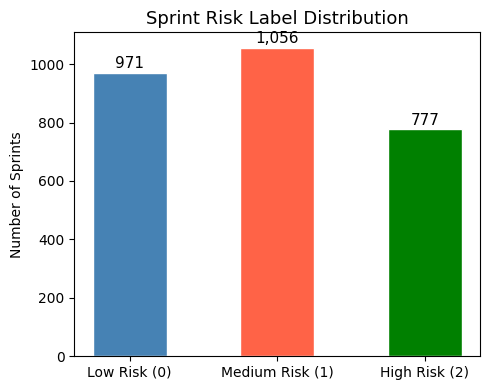

Chart saved.


In [ ]:
import matplotlib.pyplot as plt

print('=' * 55)
print('  TAWOS DATASET PREPARATION SUMMARY')
print('=' * 55)
print(f'  Total sprints in final dataset  : {len(final_df):>6,}')
print(f'  Total features                  : {len(ALL_FEATURES):>6}')
print(f'    Technical features            : {len([f for f in TECHNICAL_FEATURES if f in ALL_FEATURES]):>6}')
print(f'    Human features                : {len([f for f in HUMAN_FEATURES if f in ALL_FEATURES]):>6}')
print(f'    Process features              : {len([f for f in PROCESS_FEATURES if f in ALL_FEATURES]):>6}')
print(f'  Low risk sprints  (label=0)     : {(final_df["risk_level"]==0).sum():>6,}')
print(f'  Medium risk sprints (label=1)    : {(final_df["risk_level"]==1).sum():>6,}')
print(f'  High risk sprints (label=2)     : {(final_df["risk_level"]==2).sum():>6,}')
print(f'  Overall risk mean (labels 0,1,2) : {final_df["risk_level"].mean():>6.1%}')
print('=' * 55)
print()
print('Output files saved:')
print('  01_sprint_risk_full_2.csv     — full feature matrix')
print('  02_technical_features_2.csv   — technical factors only')
print('  03_human_features_2.csv       — human factors only')
print('  04_process_features_2.csv     — process factors only')
print('  05_feature_dictionary_2.csv   — feature labels for thesis')

# Plot class balance
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
# Sort the counts by index to ensure correct order for plotting
counts = final_df['risk_level'].value_counts().sort_index()
bars = ax.bar(['Low Risk (0)', 'Medium Risk (1)', 'High Risk (2)'], counts.values,
               color=['steelblue', 'tomato', 'green'], edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val:,}', ha='center', va='bottom', fontsize=11)
ax.set_title('Sprint Risk Label Distribution', fontsize=13)
ax.set_ylabel('Number of Sprints')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TAWOS/label_distribution_2.png', dpi=150)
plt.show()
print('Chart saved.')

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv(OUTPUT_PATH + '01_sprint_risk_full_2.csv')

FEATURE_COLS = [c for c in df.columns
                if c not in ['sprint_id', 'risk_level']]
X = df[FEATURE_COLS]
y = df['risk_level']

# Split BEFORE scaling — critical to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Fit scaler on training data only, then apply to both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # transform only, NOT fit_transform

print(f"Train: {X_train_scaled.shape}  Test: {X_test_scaled.shape}")

Train: (2243, 24)  Test: (561, 24)


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE: {pd.Series(y_train).value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y_train_bal).value_counts().to_dict()}")

Before SMOTE: {1: 845, 0: 777, 2: 621}
After SMOTE:  {1: 845, 2: 845, 0: 845}


In [ ]:
import pandas as pd

df = pd.read_csv(OUTPUT_PATH + '01_sprint_risk_full_2.csv')
FEATURE_COLS = [c for c in df.columns if c not in ['sprint_id','risk_level']]

# Check missing values
missing = df[FEATURE_COLS].isnull().sum()
print("Missing values per feature:")
print(missing[missing > 0] if missing.any() else "None — all clean")

# Check zero-variance features
zero_var = [c for c in FEATURE_COLS if df[c].std() == 0]
print(f"\nZero-variance features to drop: {zero_var if zero_var else 'None'}")

# Check near-zero variance (std < 0.01)
near_zero = [c for c in FEATURE_COLS if df[c].std() < 0.01]
print(f"Near-zero variance features:    {near_zero if near_zero else 'None'}")

# Check near-zero variance (std < 0.01)
near_zero = [c for c in FEATURE_COLS if df[c].std() < 0.01]
print(f"Near-zero variance features:    {near_zero if near_zero else 'None'}")

# Drop if any found
if zero_var:
    df = df.drop(columns=zero_var)
    FEATURE_COLS = [c for c in FEATURE_COLS if c not in zero_var]
    print(f"\nDropped {len(zero_var)} zero-variance features.")
    print(f"Remaining features: {len(FEATURE_COLS)}")

Missing values per feature:
None — all clean

Zero-variance features to drop: None
Near-zero variance features:    None
Near-zero variance features:    None


Highly correlated feature pairs (>0.90):
  story_pts_planned                   ↔  avg_story_pts                        r=1.0
  story_pts_planned                   ↔  story_pts_done                       r=1.0
  avg_story_pts                       ↔  story_pts_done                       r=1.0


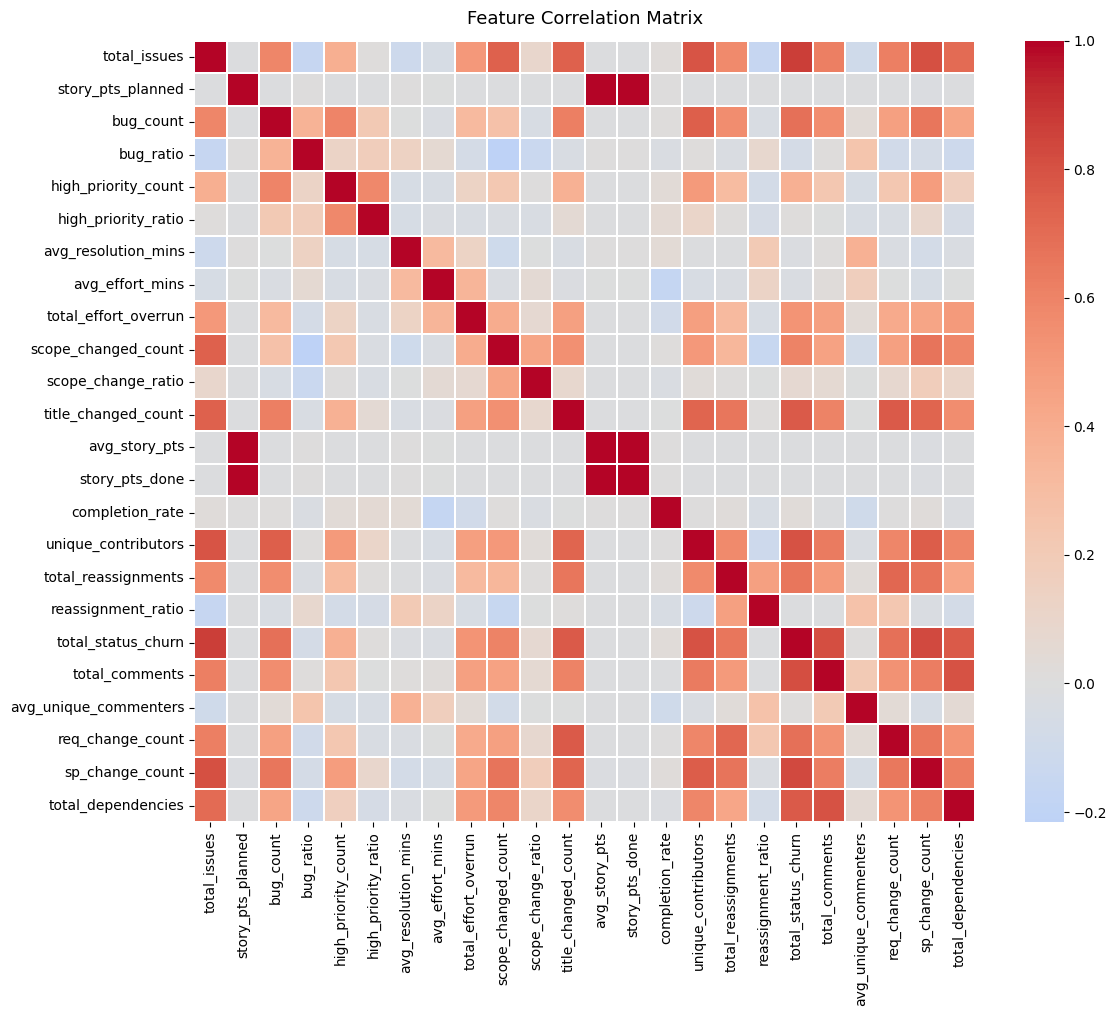

Saved: correlation_matrix_2.png


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

X = df[FEATURE_COLS]
corr = X.corr()

# Find pairs with correlation > 0.90
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.90:
            high_corr_pairs.append((
                corr.columns[i], corr.columns[j],
                round(corr.iloc[i, j], 3)
            ))

print("Highly correlated feature pairs (>0.90):")
for f1, f2, val in high_corr_pairs:
    print(f"  {f1:35s} ↔  {f2:35s}  r={val}")

# Visualise correlation matrix
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.3, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('correlation_matrix_2.png', dpi=150)
plt.show()
print("Saved: correlation_matrix_2.png")

In [ ]:
import pandas as pd
import numpy as np

OUTPUT_PATH = '/content/drive/MyDrive/TAWOS/' # Re-using OUTPUT_PATH variable

# ── CORRECT APPROACH: remove label-defining features from X ─────
df = pd.read_csv(OUTPUT_PATH + '01_sprint_risk_full_2.csv')

# These three defined your risk label ─ remove them from features
LABEL_DEFINING = [
    'completion_rate',       # directly used in label condition 1
    'total_reassignments',   # directly used in label condition 2
    'req_change_count',      # directly used in label condition 3
    # Also remove these ─ derived from story_pts_planned/done (correlated)
    'story_pts_planned',
    'avg_story_pts',
    'story_pts_done',
    'reassignment_ratio',    # derived from total_reassignments
    'desc_changed_count',    # very similar to req_change_count
    'sprint_id',             # never include ID columns
]

FEATURE_COLS = [c for c in df.columns
                if c not in LABEL_DEFINING + ['risk_level']]

print(f"Features after removing label-defining columns: {len(FEATURE_COLS)}")
print("Remaining features:")
for i, f in enumerate(FEATURE_COLS, 1):
    print(f"  {i:>2}. {f}")

Features after removing label-defining columns: 17
Remaining features:
   1. total_issues
   2. bug_count
   3. bug_ratio
   4. high_priority_count
   5. high_priority_ratio
   6. avg_resolution_mins
   7. avg_effort_mins
   8. total_effort_overrun
   9. scope_changed_count
  10. scope_change_ratio
  11. title_changed_count
  12. unique_contributors
  13. total_status_churn
  14. total_comments
  15. avg_unique_commenters
  16. sp_change_count
  17. total_dependencies


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

X = df[FEATURE_COLS].fillna(0).values
y = df['risk_level'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train_sc, y_train)

print(f"Clean feature count : {len(FEATURE_COLS)}")
print(f"Train shape         : {X_train_bal.shape}")
print(f"Test  shape         : {X_test_sc.shape}")

Clean feature count : 17
Train shape         : (2535, 17)
Test  shape         : (561, 17)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
import time

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, C=1.0
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=None,
        min_samples_leaf=2, random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6,
        learning_rate=0.1, subsample=0.8,
        use_label_encoder=False,
        eval_metric='logloss', random_state=42
    ),
    'SVM': SVC(
        kernel='rbf', C=1.0, gamma='scale',
        probability=True, random_state=42
    ),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Gradient Boosting Machine': GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=3,
        random_state=42
    ),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, learning_rate=0.1, random_state=42)
}

trained = {}
for name, model in models.items():
    print(f"Training {name}...", end=' ')
    t0 = time.time()
    model.fit(X_train_bal, y_train_bal)
    trained[name] = model
    print(f"done ({time.time()-t0:.1f}s)")

print("\nAll models trained.")

Training Logistic Regression... done (0.1s)
Training Random Forest... done (1.8s)
Training XGBoost... done (1.5s)
Training SVM... done (1.0s)
Training Naive Bayes... done (0.0s)
Training K-Nearest Neighbors... done (0.0s)
Training Gradient Boosting Machine... done (8.7s)
Training AdaBoost... done (1.3s)

All models trained.


In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)
from sklearn.model_selection import StratifiedKFold, cross_val_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

results = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in trained.items():
    # ── Test set metrics ──────────────────────────────────────────────────
    y_pred      = model.predict(X_test_sc)
    # For multiclass AUC, we need probabilities for all classes
    y_prob      = model.predict_proba(X_test_sc)

    acc  = accuracy_score(y_test, y_pred)
    # Specify average for multiclass metrics
    prec = precision_score(y_test, y_pred, average='weighted')
    rec  = recall_score(y_test, y_pred, average='weighted')
    f1   = f1_score(y_test, y_pred, average='weighted')
    # Specify multi_class and average for multiclass AUC
    auc  = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')

# ── Cross-validation AUC (more robust estimate) ───────────────────────
    cv_auc = cross_val_score(
        model, X_train_sc, y_train,
        cv=skf, scoring='roc_auc_ovr_weighted', n_jobs=-1 # Use multiclass AUC scoring
    ).mean()

    results.append({
        'Model'        : name,
        'Accuracy'     : round(acc,  4),
        'Precision'    : round(prec, 4),
        'Recall'       : round(rec,  4),
        'F1-Score'     : round(f1,   4),
        'AUC-ROC (test)': round(auc,  4),
        'CV AUC (5-fold)': round(cv_auc, 4),
    })
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    # Update target_names for multiclass output
    print(classification_report(y_test, y_pred,
          target_names=['Low Risk', 'Medium Risk', 'High Risk']))

results_df = pd.DataFrame(results).sort_values('AUC-ROC (test)', ascending=False)
print("\n=== MODEL COMPARISON TABLE ===")
print(results_df.to_string(index=False))
results_df.to_csv('model_comparison_results.csv', index=False)
print("\nSaved: model_comparison_results.csv")


  Logistic Regression
              precision    recall  f1-score   support

    Low Risk       0.76      0.85      0.80       194
 Medium Risk       0.68      0.59      0.63       211
   High Risk       0.73      0.76      0.74       156

    accuracy                           0.73       561
   macro avg       0.72      0.73      0.73       561
weighted avg       0.72      0.73      0.72       561


  Random Forest
              precision    recall  f1-score   support

    Low Risk       0.84      0.84      0.84       194
 Medium Risk       0.69      0.71      0.70       211
   High Risk       0.76      0.75      0.76       156

    accuracy                           0.76       561
   macro avg       0.77      0.77      0.77       561
weighted avg       0.77      0.76      0.76       561


  XGBoost
              precision    recall  f1-score   support

    Low Risk       0.82      0.77      0.80       194
 Medium Risk       0.66      0.68      0.67       211
   High Risk       0.75 

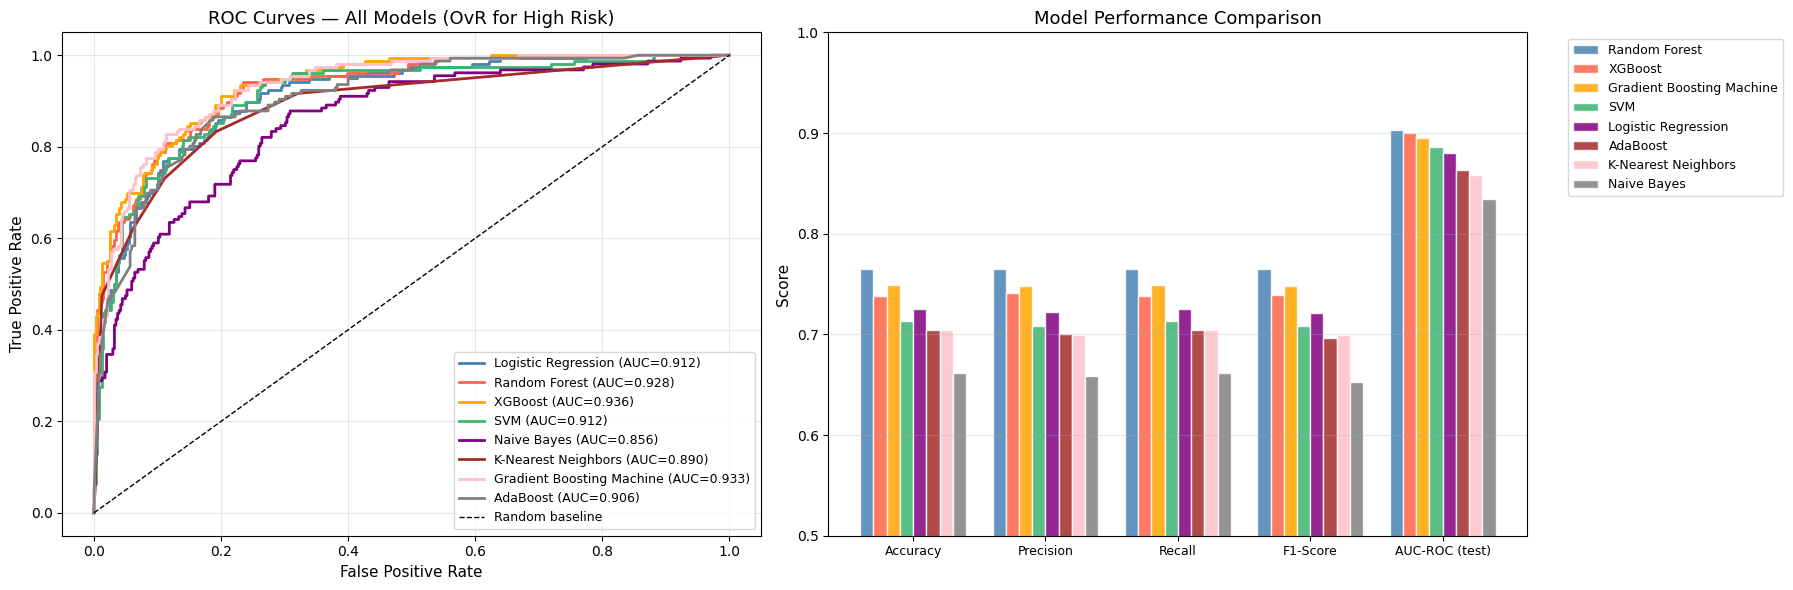

Saved: model_comparison_charts.png


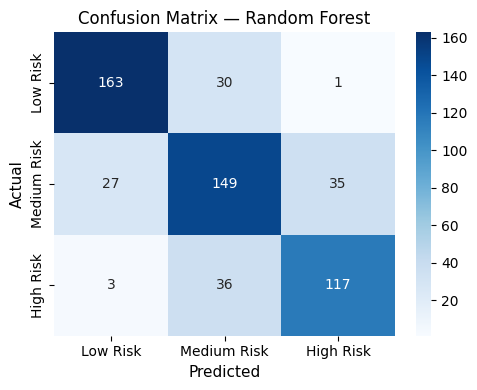

Best model: Random Forest


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize # Import for multiclass ROC

# ___ ROC Curves ________________________________________________________________
fig, axes = plt.subplots(1, 2, figsize=(18, 6)) # Increased figure size

# Define enough colors for all models
colors = [
    'steelblue', 'tomato', 'orange', 'mediumseagreen',
    'purple', 'brown', 'pink', 'gray', 'cyan', 'magenta' # Added more colors
]

# Target class to plot ROC for (e.g., 'High Risk' which is class 2)
# You can change this to 0 for 'Low Risk' or 1 for 'Medium Risk'
target_class_idx = 2 # 0: Low Risk, 1: Medium Risk, 2: High Risk
target_class_names = ['Low Risk', 'Medium Risk', 'High Risk']
target_class_name = target_class_names[target_class_idx]

# Binarize y_test for one-vs-rest ROC curve plotting
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])

# Limit colors to the number of trained models to avoid IndexError
actual_colors_roc = colors[:len(trained)]

for (name, model), color in zip(trained.items(), actual_colors_roc):
    y_prob = model.predict_proba(X_test_sc) # Full probability matrix

    # Calculate FPR, TPR for the specific target class using one-vs-rest
    fpr, tpr, _ = roc_curve(y_test_binarized[:, target_class_idx], y_prob[:, target_class_idx])
    # Recalculate AUC for this specific class for the plot legend
    class_auc = roc_auc_score(y_test_binarized[:, target_class_idx], y_prob[:, target_class_idx])

    axes[0].plot(fpr, tpr, label=f'{name} (AUC={class_auc:.3f})', color=color, lw=2)

axes[0].plot([0,1],[0,1],'k--',lw=1,label='Random baseline')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title(f'ROC Curves — All Models (OvR for {target_class_name})', fontsize=13) # Updated title
axes[0].legend(fontsize=9, loc='lower right') # Adjust legend position
axes[0].grid(True, alpha=0.3)

# ___ Metric Comparison Bar Chart _______________________________________________
metrics = ['Accuracy','Precision','Recall','F1-Score','AUC-ROC (test)']
x = np.arange(len(metrics))
num_models = len(results_df)
bar_width = 0.8 / num_models # Adjust bar width dynamically
offset_start = - (bar_width * (num_models - 1)) / 2 # Calculate start offset for centering

# Limit colors to the number of results_df entries
actual_colors_bar = colors[:num_models]

for i, (_, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics]
    axes[1].bar(x + offset_start + i * bar_width, vals, bar_width, label=row['Model'],
                color=actual_colors_bar[i], edgecolor='white', alpha=0.85)

axes[1].set_xticks(x) # Set ticks at integer positions
axes[1].set_xticklabels(metrics, fontsize=9)
axes[1].set_ylabel('Score', fontsize=11)
axes[1].set_title('Model Performance Comparison', fontsize=13)
axes[1].legend(fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left') # Adjust legend position for bar chart
axes[1].set_ylim(0.5, 1.0)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'model_comparison_charts.png', dpi=150)
plt.show()
print("Saved: model_comparison_charts.png")

# ___ Confusion Matrix for best model _______________________
best_name = results_df.iloc[0]['Model']
best_model = trained[best_name]
y_pred_best = best_model.predict(X_test_sc)
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=target_class_names, # Corrected labels for 3 classes
            yticklabels=target_class_names) # Corrected labels for 3 classes
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'confusion_matrix_best.png', dpi=150)
plt.show()
print(f"Best model: {best_name}")

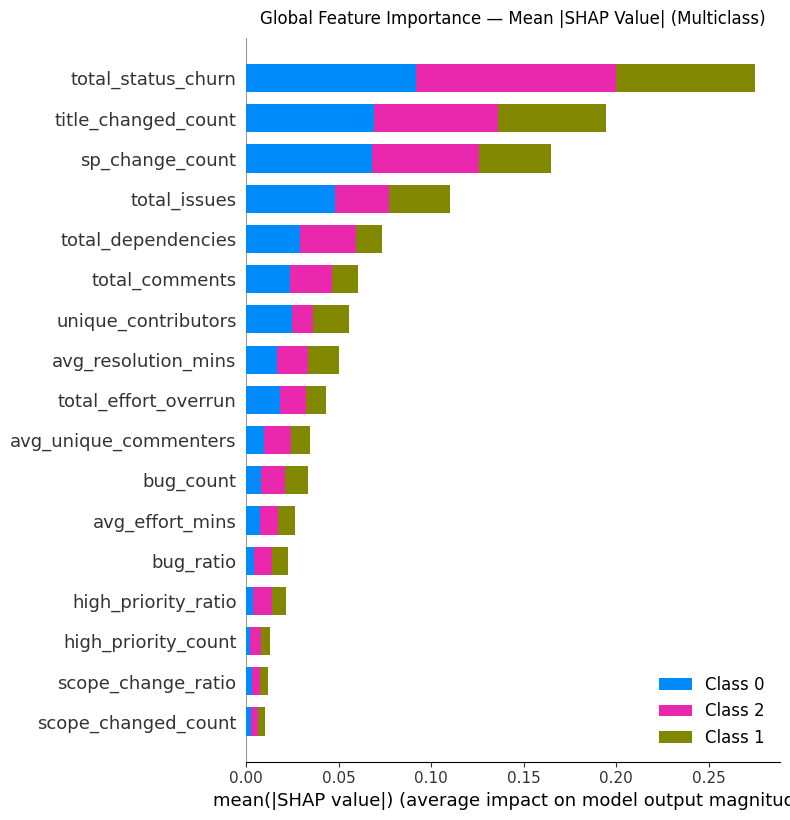

Saved: shap_global_importance_multiclass.png


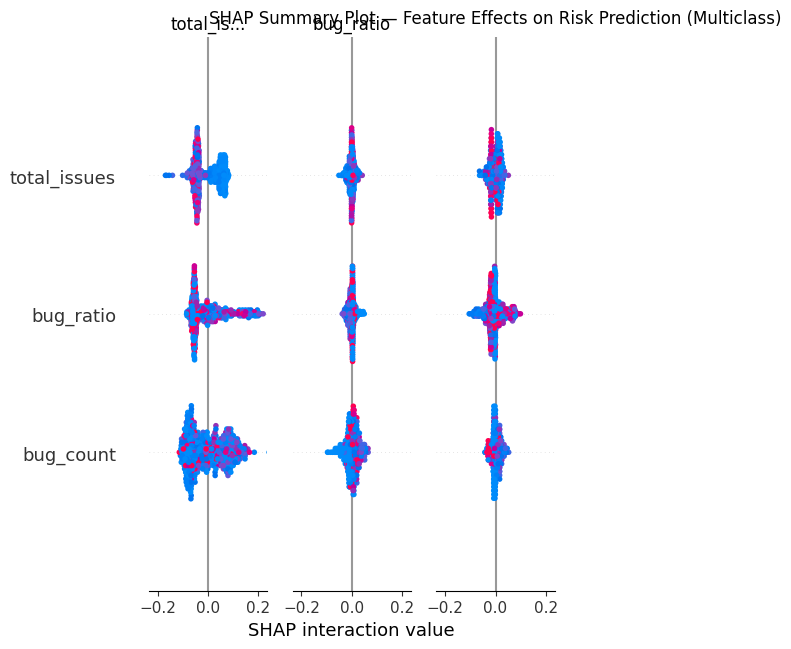

Saved: shap_beeswarm_multiclass.png


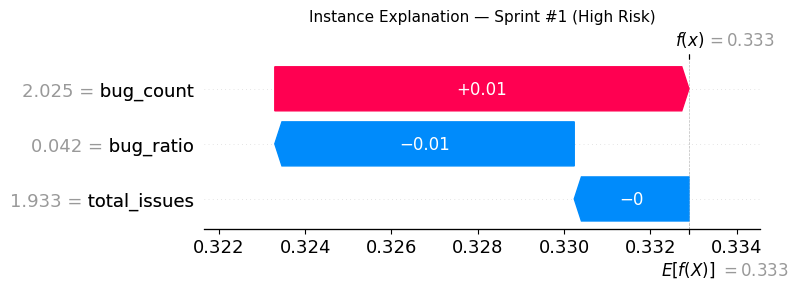

Saved: shap_waterfall_instance_high_risk.png
Best model: Random Forest


In [ ]:
!pip install shap -q
import shap
import matplotlib.pyplot as plt
import numpy as np

# Assuming `trained` dictionary, `X_test_sc`, `y_test`, and `FEATURE_COLS` are available from previous cells.

# Use TreeExplainer for tree-based models like Random Forest
best_name = results_df.iloc[0]['Model'] # Get the name of the best performing model
best_model  = trained[best_name] # Get the actual best model

# SHAP for multiclass models returns a list of arrays or a 3D array
# For multi-output classifiers like RandomForestClassifier, TreeExplainer directly outputs a list of arrays
# where each array is (n_samples, n_features) for each class.
# Or for some models it's a 3D array (n_samples, n_features, n_classes)

# If it's a RandomForestClassifier, explainer.shap_values will return a list of arrays (one per class)
# We need to compute shap_values for each class to get the correct structure for multiclass.
# The current model is RandomForest, which `TreeExplainer` handles well for multiclass.
explainer = shap.TreeExplainer(best_model)

# shap_values will be a list of arrays, one for each class, each of shape (n_samples, n_features)
shap_values = explainer.shap_values(X_test_sc)

feature_names = FEATURE_COLS # your 17 feature names

# Determine the target class for the waterfall plot (e.g., 'High Risk' which is class 2)
target_class_idx = 2 # 0: Low Risk, 1: Medium Risk, 2: High Risk
target_class_name = ['Low Risk', 'Medium Risk', 'High Risk'][target_class_idx]

# ___ Plot 1: Global feature importance (mean |SHAP|) ___________________________
# shap_values for multiclass summary plots can be passed as a list of arrays
shap.summary_plot(
    shap_values,
    X_test_sc,
    feature_names=feature_names,
    plot_type='bar',
    show=False
)
plt.title('Global Feature Importance — Mean |SHAP Value| (Multiclass)', fontsize=12, pad=10)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'shap_global_importance_multiclass.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close() # Explicitly close the plot
print("Saved: shap_global_importance_multiclass.png")

# ___ Plot 2: Beeswarm summary (shows direction of each feature's effect) ________
shap.summary_plot(
    shap_values,
    X_test_sc,
    feature_names=feature_names,
    show=False
)
plt.title('SHAP Summary Plot — Feature Effects on Risk Prediction (Multiclass)', fontsize=12, pad=10)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'shap_beeswarm_multiclass.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close() # Explicitly close the plot
print("Saved: shap_beeswarm_multiclass.png")

# ___ Plot 3: Waterfall for a single high-risk sprint instance ___________________
# Find an instance of the target class (e.g., high-risk sprint) in test set
high_risk_indices = np.where(y_test == target_class_idx)[0]

if len(high_risk_indices) == 0:
    print(f"No instances of class {target_class_name} found in the test set. Plotting for first instance of class {y_test[0]}.")
    instance_idx = 0
    waterfall_target_class_idx = y_test[0] # Use the class of the first instance
    waterfall_target_class_name = ['Low Risk', 'Medium Risk', 'High Risk'][waterfall_target_class_idx]
else:
    instance_idx = high_risk_indices[0] # Take the first high-risk instance
    waterfall_target_class_idx = target_class_idx
    waterfall_target_class_name = target_class_name

# For multiclass, shap_values is a list of arrays (n_samples, n_features), one for each class.
# Select the SHAP values for the chosen instance and target class
instance_shap_values = shap_values[waterfall_target_class_idx][instance_idx]
instance_base_value = explainer.expected_value[waterfall_target_class_idx]

shap.waterfall_plot(
    shap.Explanation(
        values        = instance_shap_values,
        base_values   = instance_base_value,
        data          = X_test_sc[instance_idx],
        feature_names = feature_names
    ),
    max_display=10, # Display top N features for clarity
    show=False
)
plt.title(f'Instance Explanation — Sprint #{instance_idx} ({waterfall_target_class_name})', fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + f'shap_waterfall_instance_{waterfall_target_class_name.lower().replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close() # Explicitly close the plot
print(f"Saved: shap_waterfall_instance_{waterfall_target_class_name.lower().replace(" ", "_")}.png")
print(f"Best model: {best_name}")

In [ ]:
import pandas as pd
import numpy as np

# Predicted probabilities for test set for each class
y_proba_all_classes = best_model.predict_proba(X_test_sc)

# Decide which class's probability and SHAP values to use for RPS
# Using 'High Risk' class (index 2) for consistency with previous SHAP interpretation
rps_target_class_idx = 2 # 0: Low Risk, 1: Medium Risk, 2: High Risk
rps_target_class_name = ['Low Risk', 'Medium Risk', 'High Risk'][rps_target_class_idx]

# Extract probabilities for the chosen target class
y_prob_target = y_proba_all_classes[:, rps_target_class_idx]

# Build risk priority score for every sprint in test set
rps_records = []
for i in range(len(X_test_sc)): # i is sample_idx
    p_risk = y_prob_target[i] # probability of the target risk class for current sprint
    for j, feat in enumerate(feature_names): # j is feature_idx
        # shap_values is a 3D array: shap_values[sample_idx][feature_idx][class_idx]
        current_shap_value = shap_values[i][j][rps_target_class_idx]
        rps = p_risk * abs(current_shap_value)
        rps_records.append({
            'sprint_idx'     : i,
            'predicted_risk' : round(p_risk, 4),
            'actual_label'   : y_test[i],
            'feature'        : feat,
            'shap_value'     : round(current_shap_value, 4),
            'feature_value'  : round(X_test_sc[i][j], 4),
            'risk_priority_score': round(rps, 4),
        })

rps_df = pd.DataFrame(rps_records)

# ── Generate sprint risk report for a specific high-risk sprint ────────
# Define risk labels for printing
risk_labels = ['LOW RISK', 'MEDIUM RISK', 'HIGH RISK']

# Find an instance of the chosen target risk class for the report
report_class_idx = rps_target_class_idx # Use the same class as for RPS calculation
report_class_name = risk_labels[report_class_idx]

report_sprint_idx_candidates = np.where(y_test == report_class_idx)[0]

if len(report_sprint_idx_candidates) == 0:
    print(f"No instances of class '{report_class_name}' found in the test set. Falling back to the first instance in the test set for the report.")
    SPRINT_IDX = 0
else:
    SPRINT_IDX = report_sprint_idx_candidates[0] # Take the first instance of the chosen risk level

report = rps_df[rps_df['sprint_idx'] == SPRINT_IDX] \
              .sort_values('risk_priority_score', ascending=False) \
              .head(5)

print(f"\n{'='*60}")
print(f"  SPRINT RISK REPORT — Sprint #{SPRINT_IDX} (Target: {report_class_name})")
print(f"  Predicted Risk Probability : {y_prob_target[SPRINT_IDX]:.1%}")
print(f"  Actual Label               : {risk_labels[y_test[SPRINT_IDX]]}")
print(f"{'='*60}")
print(f"{'Rank':<5} {'Feature':<30} {'SHAP':>8} {'RPS':>8}")
print('-'*55)
for rank, (_, row) in enumerate(report.iterrows(), 1):
    print(f"{rank:<5} {row['feature']:<30} {row['shap_value']:>8.4f} {row['risk_priority_score']:>8.4f}")
print(f"{'='*60}")


# Save full RPS table
rps_df.to_csv('risk_priority_scores_2.csv', index=False)
print("\nSaved: risk_priority_scores_2.csv")


  SPRINT RISK REPORT — Sprint #1 (Target: HIGH RISK)
  Predicted Risk Probability : 97.4%
  Actual Label               : HIGH RISK
Rank  Feature                            SHAP      RPS
-------------------------------------------------------
1     total_status_churn               0.1855   0.1806
2     title_changed_count              0.1412   0.1375
3     sp_change_count                  0.0964   0.0938
4     total_issues                     0.0689   0.0671
5     total_dependencies               0.0483   0.0471

Saved: risk_priority_scores_2.csv


In [ ]:
import joblib
from google.colab import files

# Run this in your Colab after training is complete
joblib.dump(trained['XGBoost'], 'xgb_risk_model_2.pkl')
joblib.dump(scaler,             'feature_scaler_2.pkl')
joblib.dump(FEATURE_COLS,       'feature_names_2.pkl')

print("Saved 3 files — download these to your local machine:")
print("  xgb_risk_model_2.pkl")
print("  feature_scaler_2.pkl")
print("  feature_names_2.pkl")

# Download from Colab - you might need to run these one by one
files.download('xgb_risk_model_2.pkl')
files.download('feature_scaler_2.pkl')
files.download('feature_names_2.pkl')

Saved 3 files — download these to your local machine:
  xgb_risk_model_2.pkl
  feature_scaler_2.pkl
  feature_names_2.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, textwrap, json, os
warnings.filterwarnings('ignore')

# ── 0. VERIFY PREREQUISITES ──────────────────────────────────────────────────
required = ['best_model','X_test_sc','y_test','FEATURE_COLS',
            'shap_values','rps_df','OUTPUT_PATH']
missing  = [v for v in required if v not in dir()]
if missing:
    raise NameError(
        f"Missing variables: {missing}\n"
        "Please run all previous cells in your notebook first."
    )
print("✓ All prerequisites found.")
print(f"  Test sprints   : {len(X_test_sc):,}")
print(f"  Features       : {len(FEATURE_COLS)}")
print(f"  RPS records    : {len(rps_df):,}")


✓ All prerequisites found.
  Test sprints   : 561
  Features       : 17
  RPS records    : 9,537


In [ ]:
RISK_KNOWLEDGE_BASE = {

    # ── TECHNICAL FEATURES ────────────────────────────────────────────────────
    "total_issues": {
        "dimension"      : "Technical",
        "risk_category"  : "Sprint Scope Risk",
        "iso31000_clause": "6.4.2 – Risk Identification",
        "pmbok_ka"       : "Project Scope Management (5.3)",
        "risk_driver"    : "High issue count per sprint increases delivery surface area and raises the probability of incomplete acceptance.",
        "low_actions"    : [
            "Maintain current sprint capacity — issue count is within manageable range.",
            "Continue velocity tracking to detect gradual scope creep across sprints.",
        ],
        "medium_actions" : [
            "Review backlog refinement quality; ensure all issues have complete acceptance criteria before sprint commitment.",
            "Apply WIP (Work-In-Progress) limits per PMBOK §5.3 to cap concurrent issue handling.",
            "Conduct a mid-sprint scope review against the sprint goal (ISO 31000 §6.5.1 – Risk Treatment).",
        ],
        "high_actions"   : [
            "Immediately convene a sprint scope negotiation with the Product Owner — remove low-priority issues from the sprint backlog.",
            "Re-baseline the sprint plan (PMBOK §4.3 – Direct and Manage Project Work) with a revised deliverable set.",
            "Flag as a programme-level scope risk for Steering Committee awareness per ISO 31000 §6.4.3.",
        ],
    },

    "bug_count": {
        "dimension"      : "Technical",
        "risk_category"  : "Product Quality Risk",
        "iso31000_clause": "6.4.2 – Risk Identification; 6.5.2 – Risk Treatment Options",
        "pmbok_ka"       : "Project Quality Management (8.2)",
        "risk_driver"    : "Elevated bug counts signal technical debt accumulation and defect injection rates that threaten sprint completion and downstream product quality.",
        "low_actions"    : [
            "Maintain current test coverage and code review cadence.",
            "Log bug patterns in the retrospective for trend analysis.",
        ],
        "medium_actions" : [
            "Introduce mandatory peer code review for all PRs in this sprint (PMBOK §8.2 – Manage Quality).",
            "Allocate a fixed time-box (e.g., 20% of daily capacity) to bug resolution before new feature work.",
            "Apply root cause clustering: identify which components are generating the most defects.",
        ],
        "high_actions"   : [
            "Declare a quality freeze — halt new feature development until the critical bug backlog is reduced below team threshold.",
            "Trigger a formal quality audit per PMBOK §8.2.2.1 (Quality Audits) and document findings.",
            "Escalate to Technical Lead for architectural review; consider refactoring the highest-defect module.",
            "Notify the Risk Owner per ISO 31000 §6.6 (Monitoring and Review) and update the risk register.",
        ],
    },

    "bug_ratio": {
        "dimension"      : "Technical",
        "risk_category"  : "Product Quality Risk",
        "iso31000_clause": "6.4.3 – Risk Analysis",
        "pmbok_ka"       : "Project Quality Management (8.1)",
        "risk_driver"    : "Bug-to-total-issue ratio indicates the proportion of the sprint consumed by defect work, crowding out planned feature delivery.",
        "low_actions"    : ["Bug ratio is healthy. Continue current quality practices."],
        "medium_actions" : [
            "Introduce a defect density threshold (e.g., no more than 25% of sprint issues as bugs) as a sprint health KPI.",
            "Review Definition of Done to ensure quality gates are applied consistently.",
        ],
        "high_actions"   : [
            "Halt new story intake; redirect team capacity to defect resolution.",
            "Schedule emergency retrospective focused on quality process gaps.",
            "Engage QA lead to perform a sprint-level quality risk assessment per ISO 31000 §6.4.3.",
        ],
    },

    "high_priority_count": {
        "dimension"      : "Technical",
        "risk_category"  : "Sprint Priority Risk",
        "iso31000_clause": "6.4.2 – Risk Identification; 6.5 – Risk Treatment",
        "pmbok_ka"       : "Project Scope Management (5.5); Stakeholder Management (13.3)",
        "risk_driver"    : "High-priority issues carry implicit delivery commitments to stakeholders; their accumulation in a single sprint creates concentrated failure impact.",
        "low_actions"    : ["Priority distribution is manageable. Maintain stakeholder communication cadence."],
        "medium_actions" : [
            "Confirm with Product Owner that all high-priority items have a realistic path to completion this sprint.",
            "Assign senior team members as owners for each high-priority issue.",
        ],
        "high_actions"   : [
            "Escalate to Programme Manager: the concentration of high-priority items in this sprint poses a material delivery risk.",
            "Negotiate priority deferral with stakeholders for items that cannot be guaranteed this sprint (PMBOK §13.3).",
            "Apply risk-adjusted sprint planning for next sprint to re-distribute priority load.",
        ],
    },

    "high_priority_ratio": {
        "dimension"      : "Technical",
        "risk_category"  : "Sprint Priority Risk",
        "iso31000_clause": "6.4.3 – Risk Analysis",
        "pmbok_ka"       : "Project Scope Management (5.5)",
        "risk_driver"    : "When the majority of sprint issues are high-priority, any single blockage cascades into a high-impact delivery failure.",
        "low_actions"    : ["Priority ratio is within acceptable bounds."],
        "medium_actions" : ["Review sprint goal alignment: ensure the sprint goal is achievable even if one high-priority item slips."],
        "high_actions"   : [
            "Invoke risk response plan: redistribute at least 30% of high-priority items to next sprint.",
            "Document the prioritisation decision and rationale for audit trail per ISO 31000 §6.7 (Documentation).",
        ],
    },

    "avg_resolution_mins": {
        "dimension"      : "Technical",
        "risk_category"  : "Delivery Velocity Risk",
        "iso31000_clause": "6.4.3 – Risk Analysis (Quantitative)",
        "pmbok_ka"       : "Project Schedule Management (6.4)",
        "risk_driver"    : "High average resolution time per issue indicates either structural complexity underestimation or systemic team blockers that threaten sprint throughput.",
        "low_actions"    : ["Resolution time is within expected bounds. Monitor for trend changes."],
        "medium_actions" : [
            "Identify the top 3 longest-running issues and investigate blockers in daily stand-up.",
            "Apply timeboxing per PMBOK §6.4: set explicit resolution time limits and trigger escalation if exceeded.",
        ],
        "high_actions"   : [
            "Conduct an immediate impediment analysis: categorise blockers as technical, organisational, or external.",
            "Escalate organisational blockers to the Scrum Master / Programme Manager for same-day resolution.",
            "Consider pair programming or swarming on the highest-duration issues to unblock progress.",
        ],
    },

    "avg_effort_mins": {
        "dimension"      : "Technical",
        "risk_category"  : "Effort Estimation Risk",
        "iso31000_clause": "6.4.3 – Risk Analysis",
        "pmbok_ka"       : "Project Resource Management (9.2); Schedule Management (6.4)",
        "risk_driver"    : "High average effort per issue relative to sprint capacity indicates estimation inaccuracy or unplanned complexity that threatens timely completion.",
        "low_actions"    : ["Average effort is aligned with sprint capacity. Continue estimation calibration."],
        "medium_actions" : [
            "Run an effort variance analysis comparing estimated vs actual effort per issue.",
            "Flag systematically underestimated issue types for backlog refinement adjustment.",
        ],
        "high_actions"   : [
            "Activate resource reallocation: identify team members with available capacity and reassign to overloaded issues.",
            "Conduct an estimation retrospective to recalibrate story point mapping for this team.",
            "Report effort variance to the Risk Register per ISO 31000 §6.4.2 and update sprint forecast.",
        ],
    },

    "total_effort_overrun": {
        "dimension"      : "Technical",
        "risk_category"  : "Cost / Effort Risk",
        "iso31000_clause": "6.5.1 – Risk Treatment: Avoid, Reduce, Transfer, Retain",
        "pmbok_ka"       : "Project Cost Management (7.4 – Control Costs); EVM",
        "risk_driver"    : "Cumulative effort overrun across sprint issues signals systemic underestimation or scope expansion that will compound if unaddressed.",
        "low_actions"    : ["Effort is on track. Validate story point mapping is current."],
        "medium_actions" : [
            "Apply Earned Value Management (EVM) metrics: compute CPI (Cost Performance Index) for the sprint.",
            "If CPI < 0.9, notify the Product Owner and discuss scope reduction.",
        ],
        "high_actions"   : [
            "Trigger formal Variance Analysis per PMBOK §7.4.2.1: document root causes of effort overrun.",
            "Escalate to Programme Manager with a revised sprint forecast and recovery plan.",
            "Consider story splitting: decompose remaining large stories into sub-tasks deliverable within the sprint.",
        ],
    },

    "scope_changed_count": {
        "dimension"      : "Technical",
        "risk_category"  : "Scope Creep Risk",
        "iso31000_clause": "6.4.2 – Risk Identification; 6.5.2 – Risk Treatment",
        "pmbok_ka"       : "Project Scope Management (5.6 – Control Scope)",
        "risk_driver"    : "Frequent story point changes after estimation indicate scope instability that degrades team predictability and sprint reliability.",
        "low_actions"    : ["Scope changes are minimal. Maintain sprint backlog integrity protocols."],
        "medium_actions" : [
            "Enforce a sprint backlog freeze policy: no scope changes after Sprint Day 2 without formal change request.",
            "Document scope change triggers for retrospective root cause analysis.",
        ],
        "high_actions"   : [
            "Initiate a formal Scope Change Control process per PMBOK §5.6: all changes require Product Owner + Scrum Master sign-off.",
            "Apply ISO 31000 §6.5.1 (Avoidance): reject further scope changes for this sprint and park in next sprint backlog.",
            "Add 'scope volatility' as a standing risk item in the project risk register.",
        ],
    },

    "scope_change_ratio": {
        "dimension"      : "Technical",
        "risk_category"  : "Scope Creep Risk",
        "iso31000_clause": "6.4.3 – Risk Analysis",
        "pmbok_ka"       : "Project Scope Management (5.6)",
        "risk_driver"    : "A high proportion of issues with post-estimation scope changes undermines sprint planning reliability and team confidence.",
        "low_actions"    : ["Scope change ratio is acceptable."],
        "medium_actions" : ["Review estimation process quality in next refinement session."],
        "high_actions"   : [
            "Mandate Planning Poker re-estimation for all sprint items showing scope drift.",
            "Report to Risk Owner: scope change ratio exceeds acceptable threshold per agreed risk appetite.",
        ],
    },

    "title_changed_count": {
        "dimension"      : "Technical",
        "risk_category"  : "Requirements Clarity Risk",
        "iso31000_clause": "6.4.2 – Risk Identification",
        "pmbok_ka"       : "Project Scope Management (5.3 – Define Scope); Requirements Management",
        "risk_driver"    : "Frequent issue title changes signal unclear or evolving requirements that prevent stable sprint execution and increase rework likelihood.",
        "low_actions"    : ["Requirements are stable. Continue backlog refinement discipline."],
        "medium_actions" : [
            "Flag issues with title changes for a requirements clarification conversation with the Product Owner.",
            "Introduce a Definition of Ready (DoR) checklist that requires stable titles before sprint commitment.",
        ],
        "high_actions"   : [
            "Conduct an emergency requirements review with stakeholders: ambiguous requirements must be resolved before sprint execution continues.",
            "Apply PMBOK §5.3 (Define Scope): document acceptance criteria for all remaining issues and obtain written sign-off.",
            "Log 'requirements instability' as a HIGH risk in the ISO 31000 risk register with assigned owner.",
        ],
    },

    # ── HUMAN FEATURES ────────────────────────────────────────────────────────
    "unique_contributors": {
        "dimension"      : "Human",
        "risk_category"  : "Team Capacity Risk",
        "iso31000_clause": "6.4.2 – Risk Identification; 6.5 – Risk Treatment",
        "pmbok_ka"       : "Project Resource Management (9.3 – Acquire Resources; 9.6 – Control Resources)",
        "risk_driver"    : "Very low unique contributor counts indicate key-person dependency; very high counts indicate coordination overhead and knowledge fragmentation.",
        "low_actions"    : ["Team contributor balance is healthy."],
        "medium_actions" : [
            "Review knowledge distribution: ensure no single team member is the sole owner of a critical sprint component.",
            "Implement cross-training or pair programming to reduce key-person dependency.",
        ],
        "high_actions"   : [
            "Conduct a Bus Factor analysis: identify single points of failure in the team and activate knowledge transfer.",
            "Escalate resource risk to Resource Manager per PMBOK §9.6 and request contingency staffing.",
            "Update the risk register with 'team capacity' as a HIGH risk and assign mitigation owner.",
        ],
    },

    "total_status_churn": {
        "dimension"      : "Human",
        "risk_category"  : "Workflow Process Risk",
        "iso31000_clause": "6.4.3 – Risk Analysis; 6.5.2 – Risk Treatment",
        "pmbok_ka"       : "Project Integration Management (4.5 – Monitor and Control); Quality Management (8.3)",
        "risk_driver"    : "Excessive workflow status transitions indicate rework cycles, unclear Definition of Done, or blocked issues being repeatedly re-opened — the single strongest predictor of sprint risk in this model.",
        "low_actions"    : ["Status churn is low. Definition of Done is functioning well."],
        "medium_actions" : [
            "Audit the Definition of Done: verify all team members apply acceptance criteria consistently.",
            "In the daily stand-up, specifically ask: 'Which issues have changed status more than twice this sprint?'",
            "Use a Kanban-style visual board to surface status churn patterns in real time.",
        ],
        "high_actions"   : [
            "IMMEDIATE ACTION: Investigate the top 5 highest-churn issues — are they blocked, unclear, or technically infeasible?",
            "Convene an unplanned retrospective to diagnose systemic workflow breakdown (ISO 31000 §6.5.1 – Reduce).",
            "Apply PMBOK §8.3 (Control Quality): enforce a mandatory QA sign-off before any issue moves to 'Done'.",
            "Report status churn as a HIGH process risk to the Steering Committee with a remediation timeline.",
        ],
    },

    "total_comments": {
        "dimension"      : "Human",
        "risk_category"  : "Communication Risk",
        "iso31000_clause": "6.4.2 – Risk Identification",
        "pmbok_ka"       : "Project Communications Management (10.2 – Manage Communications)",
        "risk_driver"    : "Abnormally high comment volume per sprint signals ambiguity, unresolved disputes, or excessive clarification overhead that consumes capacity without advancing delivery.",
        "low_actions"    : ["Communication volume is normal."],
        "medium_actions" : [
            "Review the issues with the highest comment counts — are clarifications that should have been resolved in refinement?",
            "Strengthen the Definition of Ready to reduce in-sprint clarification needs.",
        ],
        "high_actions"   : [
            "Flag high-comment issues for a synchronous resolution call today — asynchronous discussion is not resolving ambiguity.",
            "Apply PMBOK §10.2 (Manage Communications): establish a clear communication protocol for issue clarifications.",
            "Include 'communication overhead' in the sprint retrospective as a process improvement item.",
        ],
    },

    "avg_unique_commenters": {
        "dimension"      : "Human",
        "risk_category"  : "Stakeholder Engagement Risk",
        "iso31000_clause": "6.4.2 – Risk Identification",
        "pmbok_ka"       : "Stakeholder Management (13.3 – Manage Stakeholder Engagement)",
        "risk_driver"    : "High average unique commenters per issue indicates broad stakeholder involvement in execution-level decisions, which can slow resolution velocity.",
        "low_actions"    : ["Collaboration breadth is appropriate."],
        "medium_actions" : [
            "Designate a single decision-making authority for each issue to prevent committee-driven delays.",
        ],
        "high_actions"   : [
            "Apply RACI (Responsible, Accountable, Consulted, Informed) matrix to all active sprint issues.",
            "Limit issue-level commentary to directly responsible team members; escalate cross-team decisions to a dedicated channel.",
        ],
    },

    # ── PROCESS FEATURES ──────────────────────────────────────────────────────
    "sp_change_count": {
        "dimension"      : "Process",
        "risk_category"  : "Estimation Volatility Risk",
        "iso31000_clause": "6.4.3 – Risk Analysis; 6.5 – Risk Treatment",
        "pmbok_ka"       : "Project Schedule Management (6.3 – Estimate Activity Durations)",
        "risk_driver"    : "Repeated story point re-estimation signals that initial estimates were poorly calibrated, introduction of unplanned complexity, or team disagreement on scope.",
        "low_actions"    : ["Estimation stability is good."],
        "medium_actions" : [
            "Run an estimation calibration session: compare original vs final story points for completed issues.",
            "Identify which issue types are systematically underestimated and adjust estimation heuristics.",
        ],
        "high_actions"   : [
            "Suspend story point re-estimation mid-sprint; lock all estimates and manage scope via issue addition/removal instead.",
            "Conduct a Planning Poker retrospective to recalibrate the team's estimation reference stories.",
            "Report estimation volatility as a process risk per ISO 31000 §6.4.3 and log in the risk register.",
        ],
    },

    "total_dependencies": {
        "dimension"      : "Process",
        "risk_category"  : "Dependency / Integration Risk",
        "iso31000_clause": "6.4.2 – Risk Identification; 6.5.2 – Risk Treatment",
        "pmbok_ka"       : "Project Schedule Management (6.2 – Sequence Activities); Integration Management (4.2)",
        "risk_driver"    : "High inter-issue dependency counts create cascading failure chains where a single blocked issue delays multiple dependents, compounding sprint risk.",
        "low_actions"    : ["Dependency network is manageable."],
        "medium_actions" : [
            "Visualise the dependency network for this sprint (e.g., in Jira dependency view or a simple DAG).",
            "Identify the longest dependency chain and validate that all predecessor issues are on track.",
        ],
        "high_actions"   : [
            "IMMEDIATE: Map all critical path dependencies and assign an owner to each dependency resolution.",
            "Apply PMBOK §6.2 (Sequence Activities): formally document predecessor-successor relationships and surface schedule float.",
            "Consider de-risking by splitting dependent issues: complete the independent sub-tasks this sprint and defer integration to the next.",
            "Log as an integration risk per ISO 31000 §6.4.2 with a dependency resolution deadline.",
        ],
    },
}

# Human-readable feature display names
FEATURE_DISPLAY = {
    "total_issues"          : "Total Issues in Sprint",
    "bug_count"             : "Bug Count",
    "bug_ratio"             : "Bug Ratio",
    "high_priority_count"   : "High Priority Issue Count",
    "high_priority_ratio"   : "High Priority Ratio",
    "avg_resolution_mins"   : "Avg Resolution Time (mins)",
    "avg_effort_mins"       : "Avg Effort (mins)",
    "total_effort_overrun"  : "Total Effort Overrun (mins)",
    "scope_changed_count"   : "Scope Change Count",
    "scope_change_ratio"    : "Scope Change Ratio",
    "title_changed_count"   : "Title Change Count",
    "unique_contributors"   : "Unique Contributors",
    "total_status_churn"    : "Total Status Transitions",
    "total_comments"        : "Total Comments",
    "avg_unique_commenters" : "Avg Unique Commenters",
    "sp_change_count"       : "Story Point Change Count",
    "total_dependencies"    : "Total Issue Dependencies",
}

RISK_LABELS   = {0: "LOW RISK", 1: "MEDIUM RISK", 2: "HIGH RISK"}
RISK_COLORS   = {0: "#2ecc71",  1: "#f39c12",     2: "#e74c3c"}
RISK_ICONS    = {0: "✅",        1: "⚠️",           2: "🚨"}

print("✓ Knowledge base loaded.")
print(f"  Features mapped : {len(RISK_KNOWLEDGE_BASE)}")

✓ Knowledge base loaded.
  Features mapped : 17


In [ ]:
def get_prescriptive_report(sprint_idx,
                             top_n_features  = 5,
                             rps_target_class= 2):
    """
    Generate a full prescriptive risk management report for a single sprint.

    Parameters
    ----------
    sprint_idx        : int   — row index in X_test_sc / y_test
    top_n_features    : int   — how many top risk drivers to report on
    rps_target_class  : int   — class used for RPS (2 = High Risk)

    Returns
    -------
    dict with keys:
        sprint_idx, predicted_label, actual_label, predicted_proba,
        risk_color, top_features, recommendations, framework_refs
    """
    # ── Prediction ───────────────────────────────────────────────────────────
    y_prob_all  = best_model.predict_proba(X_test_sc)
    y_pred      = best_model.predict(X_test_sc)
    pred_label  = int(y_pred[sprint_idx])
    actual_label= int(y_test[sprint_idx])
    pred_proba  = float(y_prob_all[sprint_idx, rps_target_class])
    max_proba   = float(y_prob_all[sprint_idx].max())
    pred_class_proba = float(y_prob_all[sprint_idx, pred_label])

    # ── RPS-ranked features for this sprint ──────────────────────────────────
    sprint_rps = rps_df[rps_df['sprint_idx'] == sprint_idx].copy()
    sprint_rps = sprint_rps.sort_values('risk_priority_score', ascending=False)
    top_feats  = sprint_rps.head(top_n_features)

    # ── Build recommendations per top feature ────────────────────────────────
    recommendations = []
    framework_refs  = set()

    for _, row in top_feats.iterrows():
        feat     = row['feature']
        rps_val  = row['risk_priority_score']
        shap_val = row['shap_value']
        feat_val = row['feature_value']

        kb = RISK_KNOWLEDGE_BASE.get(feat)
        if kb is None:
            continue

        # Select action tier based on predicted risk label
        if pred_label == 0:
            actions = kb['low_actions']
        elif pred_label == 1:
            actions = kb['medium_actions']
        else:
            actions = kb['high_actions']

        framework_refs.add(f"ISO 31000: {kb['iso31000_clause']}")
        framework_refs.add(f"PMBOK:     {kb['pmbok_ka']}")

        recommendations.append({
            "feature"        : feat,
            "display_name"   : FEATURE_DISPLAY.get(feat, feat),
            "dimension"      : kb['dimension'],
            "risk_category"  : kb['risk_category'],
            "rps_score"      : round(rps_val, 4),
            "shap_value"     : round(shap_val, 4),
            "feature_value"  : round(feat_val, 4),
            "risk_driver"    : kb['risk_driver'],
            "actions"        : actions,
            "iso31000_clause": kb['iso31000_clause'],
            "pmbok_ka"       : kb['pmbok_ka'],
        })

    return {
        "sprint_idx"       : sprint_idx,
        "predicted_label"  : pred_label,
        "predicted_name"   : RISK_LABELS[pred_label],
        "actual_label"     : actual_label,
        "actual_name"      : RISK_LABELS[actual_label],
        "risk_color"       : RISK_COLORS[pred_label],
        "risk_icon"        : RISK_ICONS[pred_label],
        "pred_class_proba" : pred_class_proba,
        "high_risk_proba"  : pred_proba,
        "top_features"     : top_feats,
        "recommendations"  : recommendations,
        "framework_refs"   : sorted(framework_refs),
    }


def print_prescriptive_report(report):
    """Pretty-print a prescriptive report to the Colab console."""
    sep  = "═" * 70
    sep2 = "─" * 70
    pred = report['predicted_name']
    icon = report['risk_icon']
    color_name = {0:"GREEN",1:"AMBER",2:"RED"}[report['predicted_label']]

    print(f"\n{sep}")
    print(f"  SPRINT PRESCRIPTIVE RISK REPORT  —  Sprint #{report['sprint_idx']}")
    print(sep)
    print(f"  {icon}  PREDICTED RISK LEVEL : {pred} ({color_name})")
    print(f"  📊  Confidence (predicted class) : {report['pred_class_proba']:.1%}")
    print(f"  🔴  High-Risk Probability        : {report['high_risk_proba']:.1%}")
    print(f"  🎯  ACTUAL RISK LEVEL             : {report['actual_name']}")
    print(sep)

    print("\n  ┌─ TOP RISK DRIVERS (Risk Priority Score Ranking) ─────────────┐")
    for i, rec in enumerate(report['recommendations'], 1):
        dim_badge = f"[{rec['dimension'][:4].upper()}]"
        print(f"\n  #{i}  {rec['display_name']}  {dim_badge}")
        print(f"      Risk Category : {rec['risk_category']}")
        print(f"      RPS Score     : {rec['rps_score']:.4f}   │   SHAP: {rec['shap_value']:+.4f}")
        print(f"      Risk Driver   : {textwrap.fill(rec['risk_driver'], width=62, subsequent_indent='                    ')}")
    print("  └──────────────────────────────────────────────────────────────┘")

    print(f"\n{sep2}")
    print("  📋  PRESCRIPTIVE RECOMMENDATIONS")
    print(f"  Framework: ISO 31000:2018 (Risk Management) + PMBOK 7th Ed.")
    print(sep2)

    for i, rec in enumerate(report['recommendations'], 1):
        print(f"\n  ▶  {i}. {rec['display_name'].upper()}  [{rec['dimension']}]")
        print(f"     ISO 31000 : {rec['iso31000_clause']}")
        print(f"     PMBOK     : {rec['pmbok_ka']}")
        print(f"     Actions:")
        for j, action in enumerate(rec['actions'], 1):
            wrapped = textwrap.fill(action, width=60,
                                    initial_indent    = f"       {j}. ",
                                    subsequent_indent = "          ")
            print(wrapped)

    print(f"\n{sep2}")
    print("  📚  FULL FRAMEWORK REFERENCES FOR THIS SPRINT")
    print(sep2)
    for ref in report['framework_refs']:
        print(f"  • {ref}")
    print(f"\n{sep}\n")


print("✓ Recommendation engine defined.")

✓ Recommendation engine defined.


In [ ]:
print("\n" + "═"*70)
print("  GENERATING REPRESENTATIVE SPRINT REPORTS (1 per risk tier)")
print("═"*70)

y_pred_all = best_model.predict(X_test_sc)
sample_indices = {}
for cls in [2, 1, 0]:  # High first for impact
    candidates = np.where((y_test == cls) & (y_pred_all == cls))[0]
    if len(candidates):
        sample_indices[cls] = int(candidates[0])
    else:
        candidates = np.where(y_test == cls)[0]
        if len(candidates):
            sample_indices[cls] = int(candidates[0])

all_reports = {}
for cls in [2, 1, 0]:
    if cls not in sample_indices:
        print(f"  ⚠ No sample found for class {cls}")
        continue
    idx    = sample_indices[cls]
    report = get_prescriptive_report(idx, top_n_features=5)
    all_reports[cls] = report
    print_prescriptive_report(report)


══════════════════════════════════════════════════════════════════════
  GENERATING REPRESENTATIVE SPRINT REPORTS (1 per risk tier)
══════════════════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════════════════
  SPRINT PRESCRIPTIVE RISK REPORT  —  Sprint #1
══════════════════════════════════════════════════════════════════════
  🚨  PREDICTED RISK LEVEL : HIGH RISK (RED)
  📊  Confidence (predicted class) : 97.4%
  🔴  High-Risk Probability        : 97.4%
  🎯  ACTUAL RISK LEVEL             : HIGH RISK
══════════════════════════════════════════════════════════════════════

  ┌─ TOP RISK DRIVERS (Risk Priority Score Ranking) ─────────────┐

  #1  Total Status Transitions  [HUMA]
      Risk Category : Workflow Process Risk
      RPS Score     : 0.1806   │   SHAP: +0.1855
      Risk Driver   : Excessive workflow status transitions indicate rework cycles,
                    unclear Definition of Done, or blocked
               

In [ ]:
print("\nGenerating bulk prescriptive report for all test sprints...")

y_prob_all = best_model.predict_proba(X_test_sc)
bulk_records = []

for sprint_idx in range(len(X_test_sc)):
    pred_label = int(y_pred_all[sprint_idx])

    # Top RPS feature for this sprint
    sprint_rps  = rps_df[rps_df['sprint_idx'] == sprint_idx].sort_values(
                        'risk_priority_score', ascending=False)
    if sprint_rps.empty:
        continue
    top_row  = sprint_rps.iloc[0]
    top_feat = top_row['feature']
    kb       = RISK_KNOWLEDGE_BASE.get(top_feat, {})

    if pred_label == 0:
        actions = kb.get('low_actions', [])
    elif pred_label == 1:
        actions = kb.get('medium_actions', [])
    else:
        actions = kb.get('high_actions', [])

    primary_action = actions[0] if actions else "Review sprint metrics with Scrum Master."

    bulk_records.append({
        'sprint_test_idx'     : sprint_idx,
        'actual_risk'         : RISK_LABELS[int(y_test[sprint_idx])],
        'predicted_risk'      : RISK_LABELS[pred_label],
        'high_risk_prob'      : round(float(y_prob_all[sprint_idx, 2]), 4),
        'top_risk_driver'     : FEATURE_DISPLAY.get(top_feat, top_feat),
        'risk_category'       : kb.get('risk_category', 'N/A'),
        'top_rps_score'       : round(float(top_row['risk_priority_score']), 4),
        'top_shap_value'      : round(float(top_row['shap_value']), 4),
        'dimension'           : kb.get('dimension', 'N/A'),
        'iso31000_clause'     : kb.get('iso31000_clause', 'N/A'),
        'pmbok_knowledge_area': kb.get('pmbok_ka', 'N/A'),
        'primary_recommendation': primary_action,
    })

bulk_df = pd.DataFrame(bulk_records)
bulk_path = OUTPUT_PATH + 'prescriptive_sprint_report.csv'
bulk_df.to_csv(bulk_path, index=False)
print(f"✓ Bulk report saved: {bulk_path} ({len(bulk_df):,} rows)")
print(bulk_df[['predicted_risk','top_risk_driver','primary_recommendation']].head(6).to_string(index=False))


Generating bulk prescriptive report for all test sprints...
✓ Bulk report saved: /content/drive/MyDrive/TAWOS/prescriptive_sprint_report.csv (561 rows)
predicted_risk          top_risk_driver                                                                                               primary_recommendation
   MEDIUM RISK       Title Change Count                 Flag issues with title changes for a requirements clarification conversation with the Product Owner.
     HIGH RISK Total Status Transitions IMMEDIATE ACTION: Investigate the top 5 highest-churn issues — are they blocked, unclear, or technically infeasible?
      LOW RISK Total Status Transitions                                                         Status churn is low. Definition of Done is functioning well.
      LOW RISK Total Status Transitions                                                         Status churn is low. Definition of Done is functioning well.
     HIGH RISK Total Status Transitions IMMEDIATE ACTION: Inve


Generating Risk Driver Heatmap...


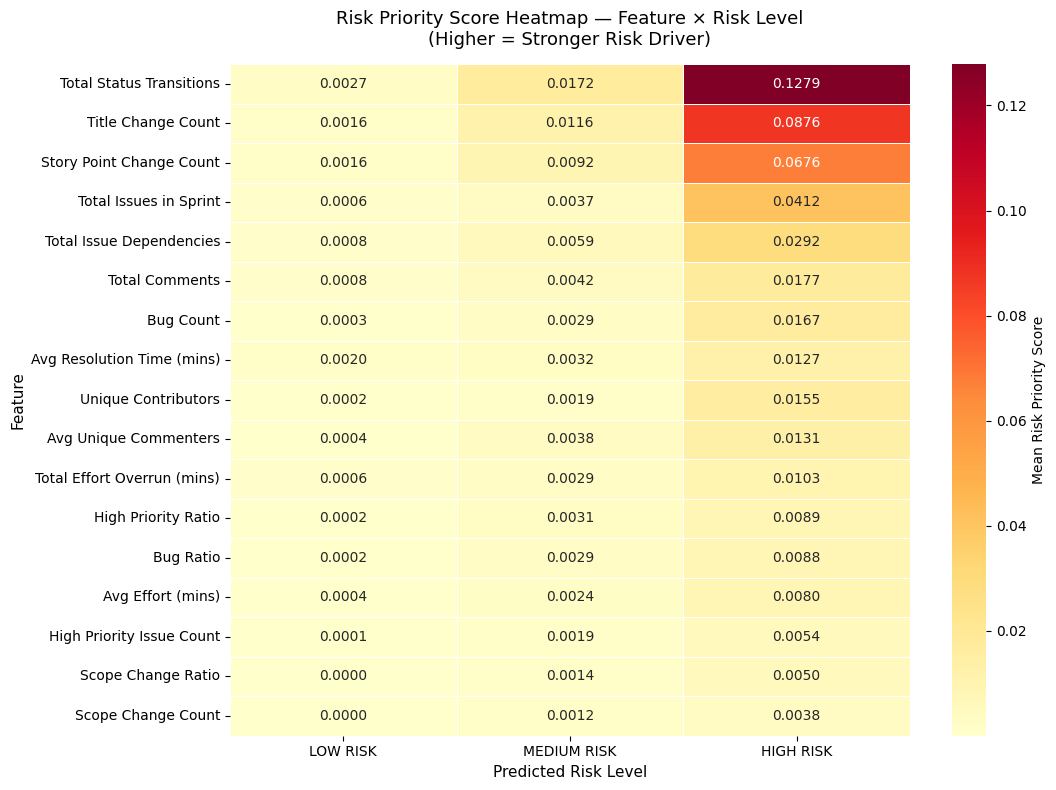

✓ Saved: prescriptive_rps_heatmap.png


In [ ]:
print("\nGenerating Risk Driver Heatmap...")

# Attach predicted labels to rps_df
pred_labels_series = pd.Series(y_pred_all, name='predicted_label')
rps_enriched = rps_df.copy()
rps_enriched['predicted_label'] = rps_enriched['sprint_idx'].map(
    dict(enumerate(y_pred_all.tolist()))
)
rps_enriched['risk_name'] = rps_enriched['predicted_label'].map(RISK_LABELS)

# Average RPS per (feature, risk_level)
heatmap_data = rps_enriched.groupby(['feature','risk_name'])['risk_priority_score'].mean().unstack(fill_value=0)
col_order = [RISK_LABELS[k] for k in [0,1,2] if RISK_LABELS[k] in heatmap_data.columns]
heatmap_data = heatmap_data[col_order]

# Sort by total RPS
heatmap_data = heatmap_data.loc[heatmap_data.sum(axis=1).sort_values(ascending=False).index]
heatmap_data.index = [FEATURE_DISPLAY.get(f, f) for f in heatmap_data.index]

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.4f', cmap='YlOrRd',
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': 'Mean Risk Priority Score'},
    ax=ax
)
ax.set_title('Risk Priority Score Heatmap — Feature × Risk Level\n(Higher = Stronger Risk Driver)',
             fontsize=13, pad=14)
ax.set_xlabel('Predicted Risk Level', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'prescriptive_rps_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: prescriptive_rps_heatmap.png")



Generating Risk Category Distribution Chart...


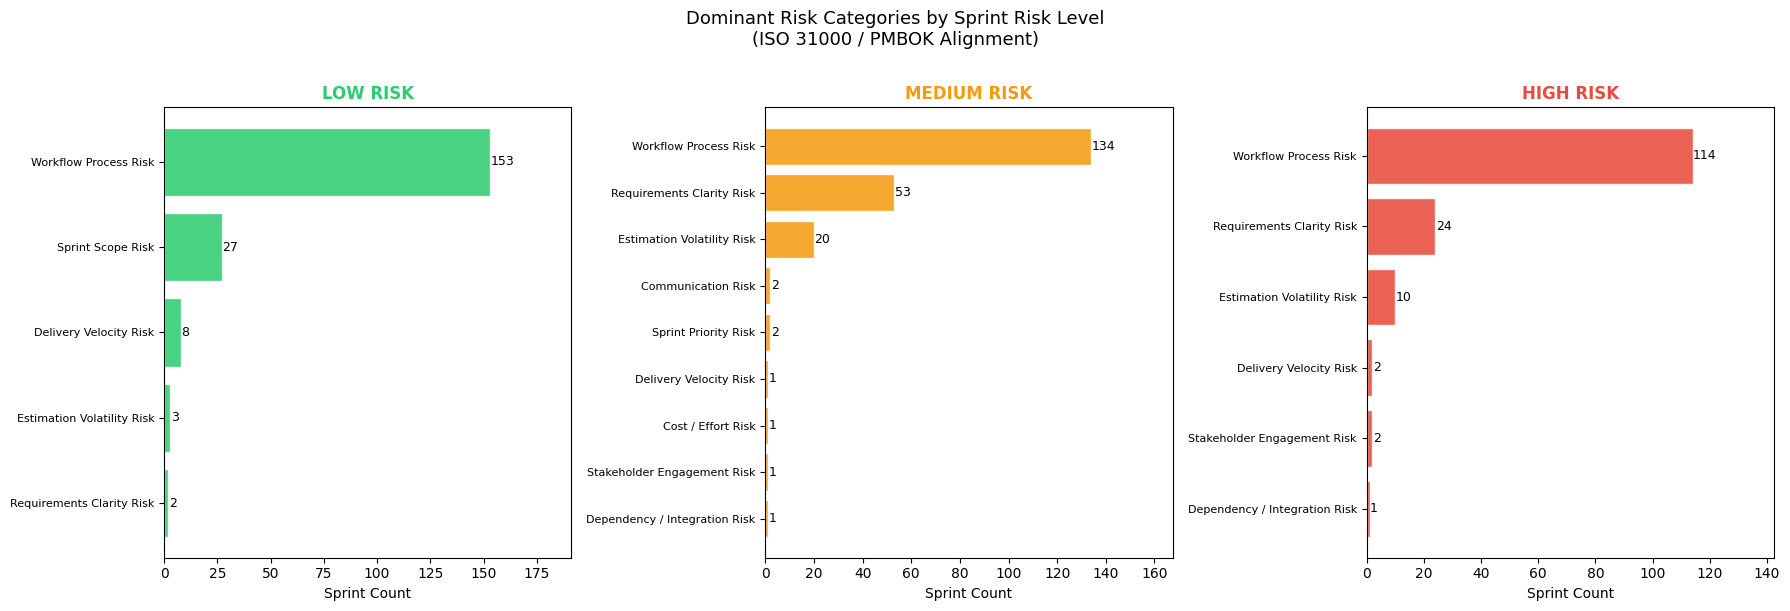

✓ Saved: prescriptive_risk_categories.png


In [ ]:
print("\nGenerating Risk Category Distribution Chart...")

# Build category-level summary from bulk report
cat_data = bulk_df.groupby(['predicted_risk','risk_category']).size().reset_index(name='count')
risk_order = ['LOW RISK','MEDIUM RISK','HIGH RISK']
cat_data['predicted_risk'] = pd.Categorical(cat_data['predicted_risk'],
                                             categories=risk_order, ordered=True)
cat_data = cat_data.sort_values('predicted_risk')

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
palette = ['#2ecc71','#f39c12','#e74c3c']

for ax, (risk_name, color) in zip(axes, zip(risk_order, palette)):
    sub = cat_data[cat_data['predicted_risk'] == risk_name].sort_values('count', ascending=True)
    if sub.empty:
        ax.set_visible(False)
        continue
    bars = ax.barh(sub['risk_category'], sub['count'], color=color, edgecolor='white', alpha=0.88)
    for bar, val in zip(bars, sub['count']):
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=9)
    ax.set_title(f'{risk_name}', fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Sprint Count')
    ax.tick_params(axis='y', labelsize=8)
    ax.set_xlim(0, sub['count'].max() * 1.25)

plt.suptitle('Dominant Risk Categories by Sprint Risk Level\n(ISO 31000 / PMBOK Alignment)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'prescriptive_risk_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: prescriptive_risk_categories.png")


Generating Pipeline Architecture Diagram...


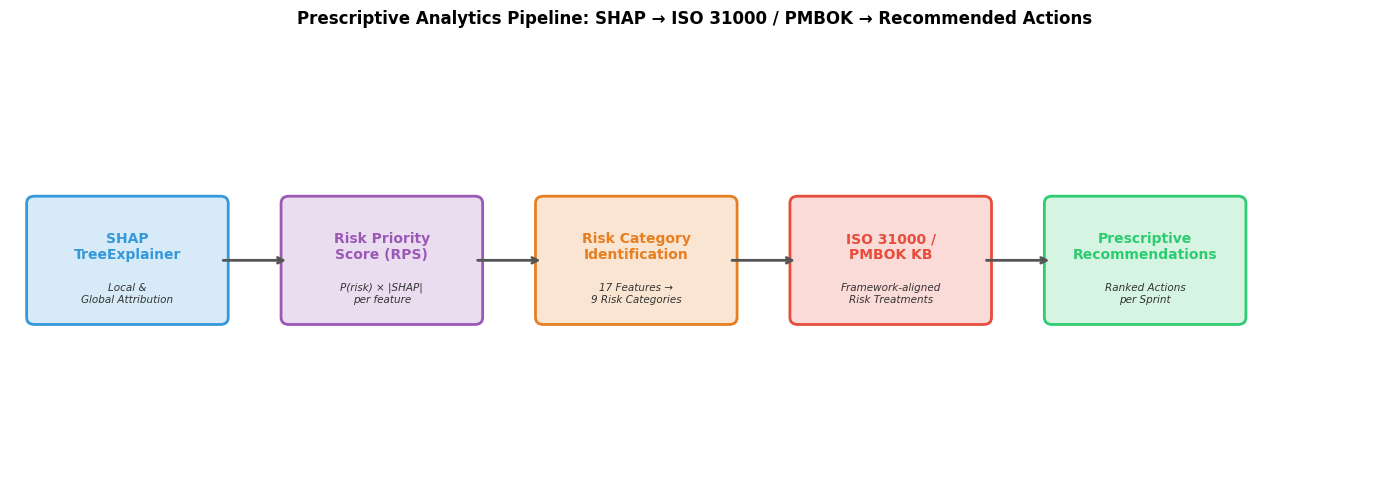

✓ Saved: prescriptive_pipeline_diagram.png


In [ ]:
print("\nGenerating Pipeline Architecture Diagram...")

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 5)
ax.axis('off')

# Pipeline stages
stages = [
    (1.2, 2.5, "SHAP\nTreeExplainer",         "#3498db", "Local &\nGlobal Attribution"),
    (3.8, 2.5, "Risk Priority\nScore (RPS)",   "#9b59b6", "P(risk) × |SHAP|\nper feature"),
    (6.4, 2.5, "Risk Category\nIdentification","#e67e22", "17 Features →\n9 Risk Categories"),
    (9.0, 2.5, "ISO 31000 /\nPMBOK KB",        "#e74c3c", "Framework-aligned\nRisk Treatments"),
    (11.6,2.5, "Prescriptive\nRecommendations","#2ecc71", "Ranked Actions\nper Sprint"),
]

box_w, box_h = 1.9, 1.3
arrow_props  = dict(arrowstyle="->", color="#555", lw=2)

for x, y, label, color, subtitle in stages:
    rect = mpatches.FancyBboxPatch(
        (x - box_w/2, y - box_h/2), box_w, box_h,
        boxstyle="round,pad=0.08", linewidth=2,
        edgecolor=color, facecolor=color + "33"
    )
    ax.add_patch(rect)
    ax.text(x, y + 0.15, label, ha='center', va='center',
            fontsize=10, fontweight='bold', color=color)
    ax.text(x, y - 0.38, subtitle, ha='center', va='center',
            fontsize=7.5, color='#333', style='italic')

# Arrows between stages
arrow_xs = [(2.15, 2.85), (4.75, 5.45), (7.35, 8.05), (9.95, 10.65)]
for x1, x2 in arrow_xs:
    ax.annotate("", xy=(x2, 2.5), xytext=(x1, 2.5), arrowprops=arrow_props)

ax.set_title("Prescriptive Analytics Pipeline: SHAP → ISO 31000 / PMBOK → Recommended Actions",
             fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'prescriptive_pipeline_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: prescriptive_pipeline_diagram.png")




Generating Dimension Contribution Chart...


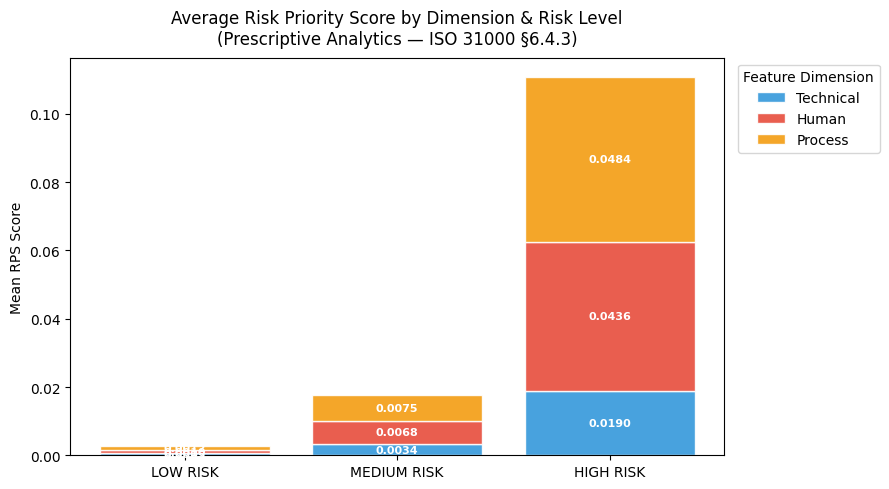

✓ Saved: prescriptive_dimension_contribution.png


In [ ]:
print("\nGenerating Dimension Contribution Chart...")

dim_map = {f: RISK_KNOWLEDGE_BASE[f]['dimension']
           for f in FEATURE_COLS if f in RISK_KNOWLEDGE_BASE}
rps_enriched['dimension'] = rps_enriched['feature'].map(dim_map)

dim_data = rps_enriched.groupby(['risk_name','dimension'])['risk_priority_score'].mean().unstack(fill_value=0)
dim_data = dim_data.reindex(risk_order).dropna(how='all')

dim_colors = {'Technical':'#3498db','Human':'#e74c3c','Process':'#f39c12'}
fig, ax = plt.subplots(figsize=(9, 5))

bottom = np.zeros(len(dim_data))
for dim in ['Technical','Human','Process']:
    if dim not in dim_data.columns:
        continue
    vals = dim_data[dim].values
    bars = ax.bar(dim_data.index, vals, bottom=bottom,
                  label=dim, color=dim_colors[dim], edgecolor='white', alpha=0.9)
    for bar, val in zip(bars, vals):
        if val > 0.0005:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_y() + bar.get_height()/2,
                    f'{val:.4f}', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
    bottom += vals

ax.set_title('Average Risk Priority Score by Dimension & Risk Level\n(Prescriptive Analytics — ISO 31000 §6.4.3)',
             fontsize=12, pad=10)
ax.set_ylabel('Mean RPS Score')
ax.legend(title='Feature Dimension', bbox_to_anchor=(1.01,1), loc='upper left')
ax.tick_params(axis='x', labelsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'prescriptive_dimension_contribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: prescriptive_dimension_contribution.png")



In [ ]:
def get_sprint_recommendation(sprint_idx, top_n=5):
    """
    Convenience wrapper — call this for any sprint index in the test set.

    Example
    -------
        get_sprint_recommendation(42)        # full report for sprint index 42
        get_sprint_recommendation(0, top_n=3) # top 3 drivers only
    """
    if sprint_idx < 0 or sprint_idx >= len(X_test_sc):
        print(f"⚠ sprint_idx must be between 0 and {len(X_test_sc)-1}")
        return None
    report = get_prescriptive_report(sprint_idx, top_n_features=top_n)
    print_prescriptive_report(report)
    return report

print("\n" + "═"*70)
print(" PRESCRIPTIVE PIPELINE COMPLETE")
print("═"*70)
print("""
OUTPUTS SAVED TO GOOGLE DRIVE (TAWOS folder):
   prescriptive_sprint_report.csv       — bulk prescriptions for all test sprints
   prescriptive_rps_heatmap.png         — RPS heatmap by feature × risk level
   prescriptive_risk_categories.png     — ISO/PMBOK risk categories per risk tier
   prescriptive_pipeline_diagram.png    — pipeline architecture diagram
   prescriptive_dimension_contribution.png — Tech/Human/Process RPS contribution

HOW TO QUERY ANY SPRINT:
  >>> get_sprint_recommendation(sprint_idx=42)
  >>> get_sprint_recommendation(sprint_idx=100, top_n=3)
""")



══════════════════════════════════════════════════════════════════════
 PRESCRIPTIVE PIPELINE COMPLETE
══════════════════════════════════════════════════════════════════════

OUTPUTS SAVED TO GOOGLE DRIVE (TAWOS folder):
   prescriptive_sprint_report.csv       — bulk prescriptions for all test sprints
   prescriptive_rps_heatmap.png         — RPS heatmap by feature × risk level
   prescriptive_risk_categories.png     — ISO/PMBOK risk categories per risk tier
   prescriptive_pipeline_diagram.png    — pipeline architecture diagram
   prescriptive_dimension_contribution.png — Tech/Human/Process RPS contribution

HOW TO QUERY ANY SPRINT:
  >>> get_sprint_recommendation(sprint_idx=42)
  >>> get_sprint_recommendation(sprint_idx=100, top_n=3)

